# Data Analytics Competition (DAC) Find IT! 2026 | bismillah kasih keras
---
**Nama Tim:**  
* bismillah kasih keras

**Anggota:**
* Andi Nabil Safaraz
* Radishta Kiriska
* Aulia Kemal Syah

**Public Score:**
* 0.79207

# Overview
Seiring dengan pesatnya perkembangan teknologi, sistem face recognition telah banyak diterapkan di berbagai sektor, seperti pembukaan kunci perangkat seluler, sistem absensi, hingga verifikasi identitas pada layanan keuangan. Meskipun memberikan kemudahan dan efisiensi, sistem ini masih memiliki kerentanan terhadap ancaman keamanan, salah satunya adalah face spoofing.

Face spoofing merupakan bentuk serangan yang bertujuan untuk mengelabui sistem pengenalan wajah dengan memanfaatkan media visual, seperti foto cetak, tampilan gambar pada layar, maupun representasi wajah lainnya. Berbagai penelitian menunjukkan bahwa serangan berbasis citra ini memiliki tingka keberhasilan yang mengkhawatirkan, terutama pada sistem yang belum dilengkapi dengan mekanisme deteksi keaslian (liveness detection) yang memadai.

**Detail Kunci:**
- **Tujuan:** Mengklasifikasikan citra wajah ke dalam kategori asli (real) atau palsu (spoof).
- **Evaluasi:** Macro F1-Score.
- **Dataset:** Direktori (train dan test) yang diekstrak secara langsung tanpa pemotongan berlapis, beserta berkas referensi sampel submisi.
- **Tantangan Utama:** Ketidakseimbangan distribusi kelas (class imbalance), generalisasi fitur terhadap berbagai jenis serangan presentasi (seperti pantulan layar digital atau keburaman foto cetak), dan optimalisasi batas ambang probabilitas.

**Objektif:**  
Kompetisi ini berfokus pada pengembangan model yang mampu melakukan klasifikasi wajah ke dalam enam kelas yang berbeda secara akurat, serta memiliki kemampuan untuk mengidentifikasi berbagai bentuk spoofing attack.



## TAHAP 1: Instalasi dan inisialisasi hardware

Pada tahap ini kami melakukan instalasi dan juga melakukan checking terhadap hardware , berikut library yang kami install :
1. **(`timm`)**: Digunakan sebagai utama untuk memuat arsitektur  (seperti ConvNeXt dan Swin Transformer).
2. **(`torch.cuda.amp`)**: Menerapkan *Automatic Mixed Precision* (AMP) menggunakan `autocast` dan `GradScaler`. Kami menggunakan ini untuk mengoptimisasi penggunan memori GPU.
3. **(`albumentations`)**: Library augmentasi yang berfungsi untuk meng simulasikan .
4. **Metrik & Keadilan Data (`sklearn`)**: Digunakan untuk weight class checking dan mengkalkulasi Macro F1-Score.
5. **(`transformers`)**: Menggunakan *Cosine Annealing with Warmup* dari Hugging Face agar konvergensi *loss* berjalan mulus.



*Cell di bawah juga akan otomatis menyambungkan Google Drive dan memverifikasi GPU yang kita miliki di Google Colab.*

In [2]:
!pip install timm albumentations transformers -q


In [3]:

import os, cv2, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import get_cosine_schedule_with_warmup

from google.colab import drive
drive.mount('/content/drive')
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('✅ Import selesai')
print('Device :', DEVICE)
if torch.cuda.is_available():
    print('GPU    :', torch.cuda.get_device_name(0))
    print('VRAM   :', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')

Mounted at /content/drive
✅ Import selesai
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## TAHAP 2: Konfigurasi Global & Hyperparameters

Disini kami mendefinisikan path . Pada bagian ini kami juga melakukan definisi batch,patience, model, img_size dan load model. Berikut penjelasan dan alasan kami menggunakan beberapa size berikut.

* **Resolusi  (`IMG_SIZE = 384`)**  : Resolusi tinggi ini kami perlukan dalam kasus *Anti-Spoofing* dengan size 384 .Size 384 dipilih karena bobot kerja yang sesuai dengan kapasitas GPU google collab T4. Model (terutama COvNext) butuh resolusi tinggi untuk menangkap mikrotekstur seperti *noise* layar, pantulan cahaya, atau serat kertas *printed*.

* **Manajemen Memori (`BATCH = 8`)**:Menyesuaikan dengan kapasitas VRAM GPU dan batch 8 menurut kami adalah sweet spot agar model raksasa dapat berlatin tanpa OOM.


* **Pengaman Latihan (`PATIENCE = 7`)**: Kami menggunakan mekanisme *Early Stopping*. Jika model tidak memecahkan rekor F1-Score selama 7 *epoch* berturut-turut, *training* akan dihentikan otomatis untuk mencegah *overfitting* dan menghemat waktu.

* **Double Architecture (Swin & ConvNeXt)**: Kami sengaja melatih dua arsitektur unggulan yang memiliki sifat berlawanan. Kami melakukan comparison kedua model ini nantinya.


## Alasan Pemilihan Model

#### Model Swin Transformer Base 384


**Swin Transformer** (*Shifted Window Transformer*) adalah arsitektur *Vision Transformer* yang diperkenalkan Microsoft Research pada 2021 [[GitHub](https://github.com/microsoft/Swin-Transformer)]. Inovasi utamanya adalah mekanisme *shifted window attention* yang memungkinkan model menghitung *self-attention* dalam window lokal yang digeser antar layer, sehingga informasi dapat mengalir antar window secara efisien.

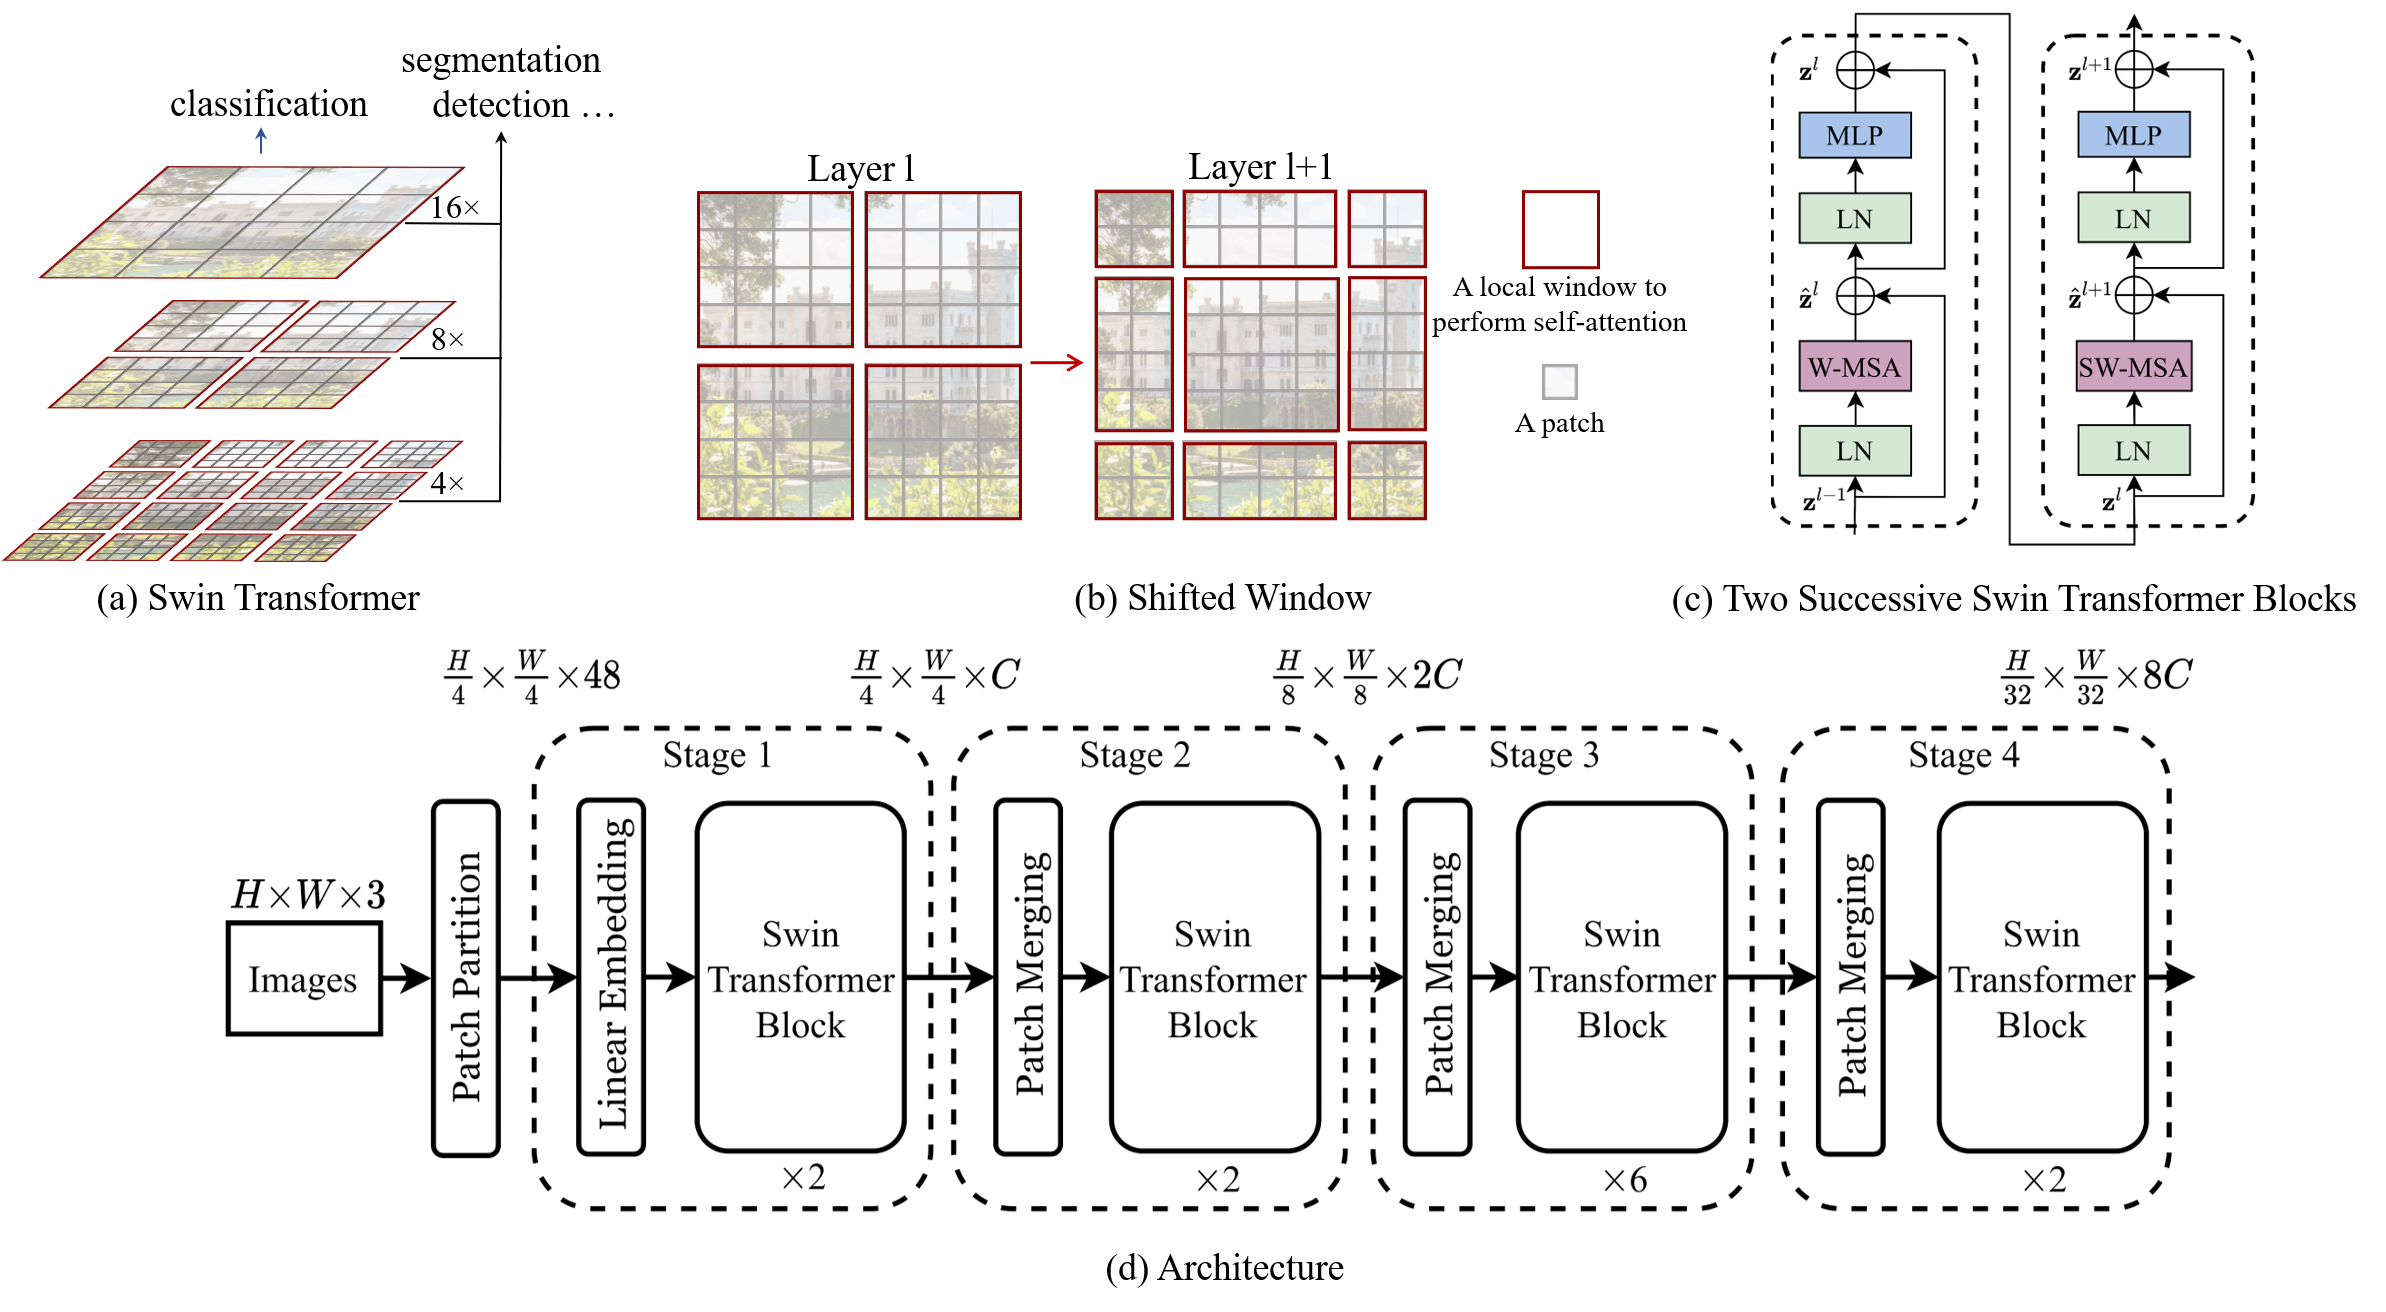

Dalam mengidentifikasi berbagai bentuk spoofing attack, dibutuhkan 2 jenis fitur yaitu fitur global yang menggambarkan karakteristik keseluruhan gambar secara umum (seperti bingkai layar pada `fake_screen`, tepi topeng pada `fake_mask`, atau tekstur tidak natural pada `fake_mannequin`) dan fitur lokal yang menggambarkan detail atau bagian spesifik dari gambar, seperti sekelompok kecil piksel, sudut, tepi, atau tekstur tertentu membutuhkan perhatian pada detail tekstur level rendah. Hierarki *window attention* pada Swin secara alami menangkap kedua fitur ini.

**Mengapa `swin_base_patch4_window12_384`:**

- **`base`** — Dengan hanya 1.654 sampel training, varian yang lebih besar (Large/Huge) akan mengalami overfitting parah. Base (~88M parameter) memberikan kapasitas yang cukup tanpa risiko tersebut.
- **`patch4`** — Setiap patch berukuran 4×4 piksel, memberikan granularitas yang cukup untuk mendeteksi artefak spoofing berukuran kecil.
- **`window12`** — Window attention berukuran 12×12 patch. Pada resolusi 384, ini setara dengan area fisik 48×48 piksel per window — cukup untuk menangkap pola tekstur spoofing yang relevan.
- **`384`** — Bobot pretrained dioptimalkan khusus untuk resolusi ini, bukan upscaling dari 224. Konsistensi resolusi pretrained-finetuning menghasilkan transfer learning yang lebih efektif.


#### Model ConvNeXt Base 384


**ConvNeXt** adalah arsitektur CNN modern yang diperkenalkan Facebook AI Research (Meta) pada 2022 [[GitHub](https://github.com/facebookresearch/ConvNeXt)]. ConvNeXt dibangun dengan filosofi *"modernizing a standard ResNet toward the design of a Vision Transformer"* — mengadopsi keputusan desain terbaik dari Transformer (inverted bottleneck, depthwise convolution, larger kernel 7×7, Layer Normalization) sambil tetap menggunakan konvolusi standar sebagai operasi inti.

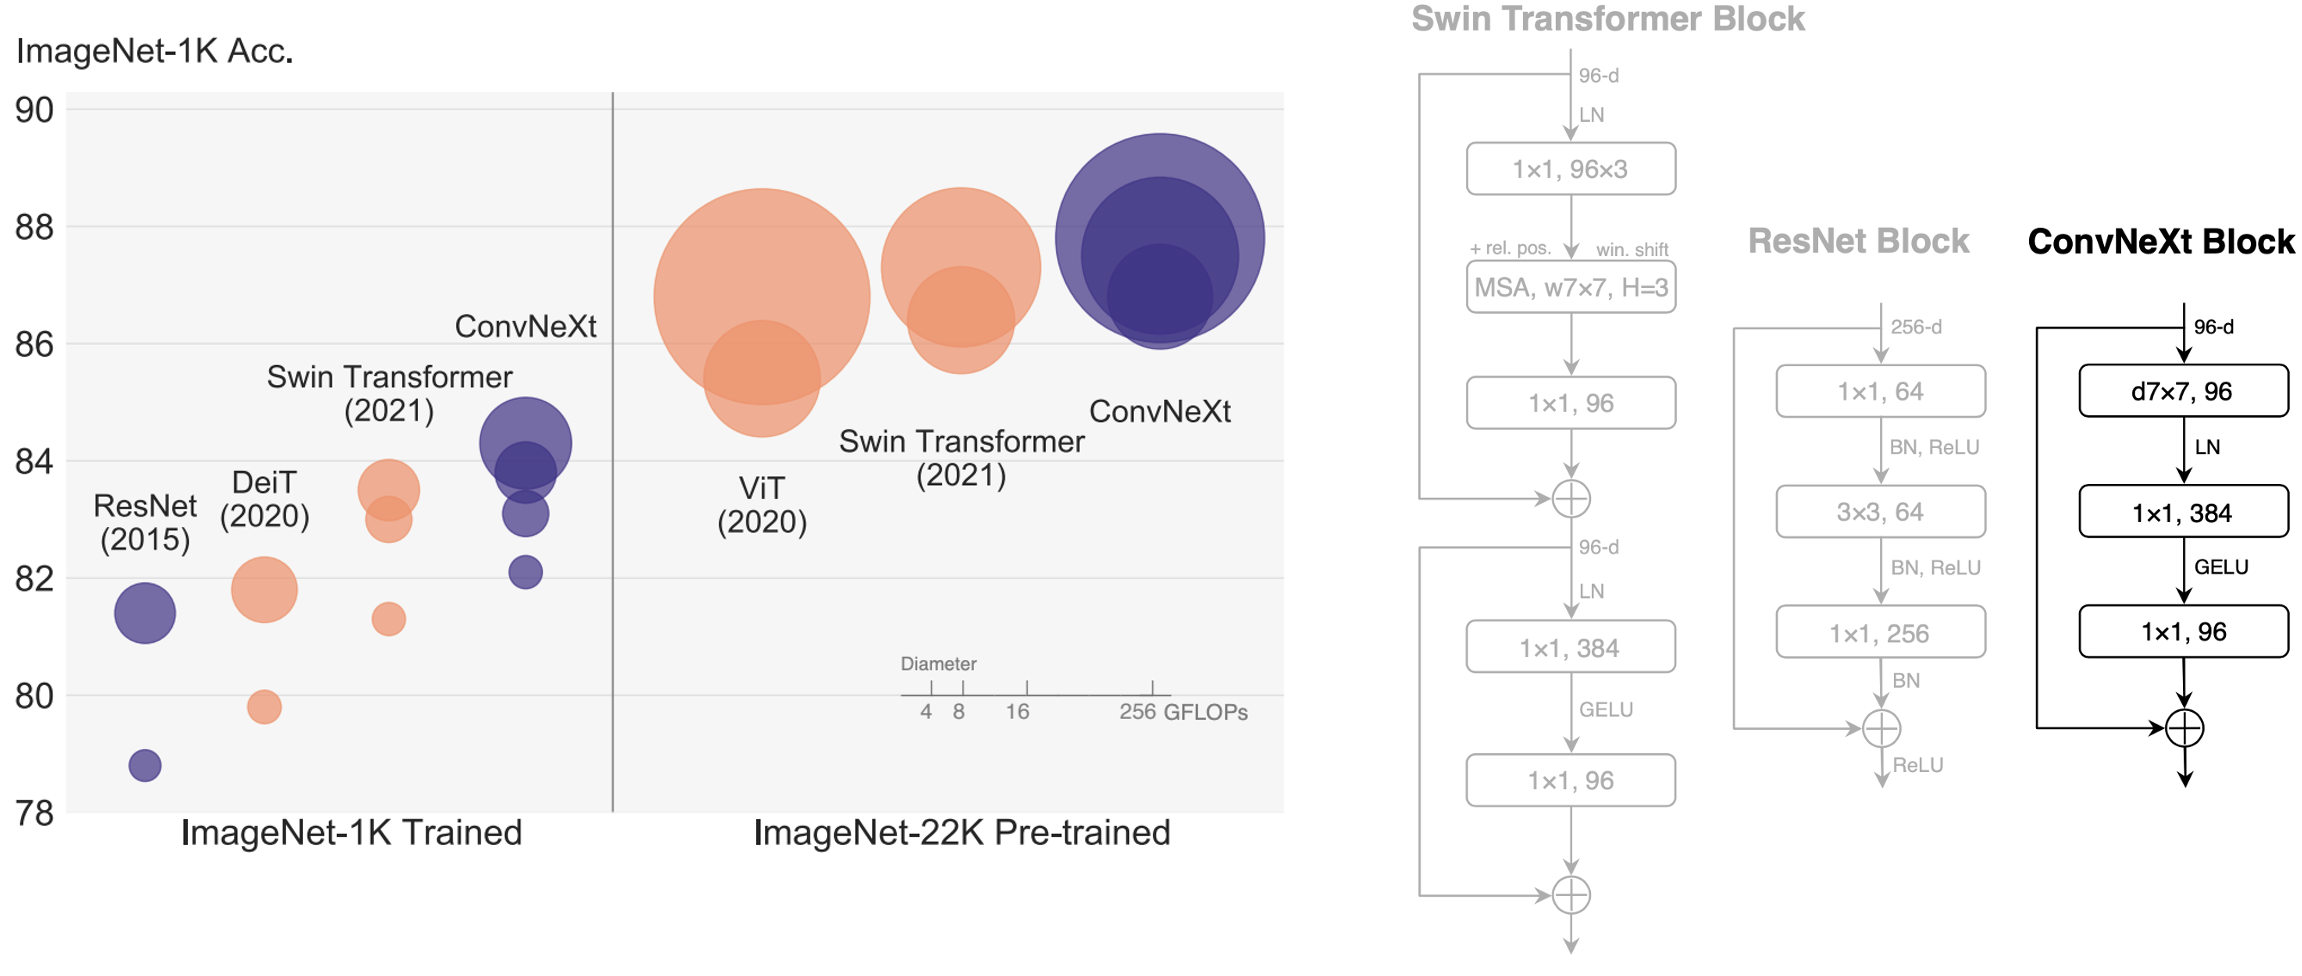

Karena ConvNeXt merupakan arsitektur CNN modern, model ini mempunyai sifat dasar yang disebut *translational equivariance* yaitu pola yang sama akan dideteksi meskipun posisinya berbeda dalam gambar. Sifat ini membuat CNN secara alami lebih peka terhadap detail tekstur halus, seperti perbedaan antara pori kulit manusia, serat kertas cetak, permukaan plastik mannequin, dan susunan piksel layar digital. Perbedaan tekstur yang biasanya sering terlihat dalam spoofing

**Mengapa `convnext_base.fb_in22k_ft_in1k_384`:**

- **`base`** — Alasan yang sama dengan Swin: tidak terlalu besar untuk 1.654 sampel.
- **`fb`** — Bobot disediakan langsung oleh Facebook Research (tim pembuat arsitektur), bukan reproduksi pihak ketiga.
- **`in22k`** — Pre-training dilakukan pada **ImageNet-22K** yang berisi 22.000 kelas dan ~14 juta gambar. Dibanding ImageNet-1K standar (1.000 kelas, ~1,2 juta gambar), representasi yang dipelajari jauh lebih kaya dan *transferable* ke task baru, sangat penting untuk dataset training yang kecil.
- **`ft_in1k`** — Setelah pre-training pada ImageNet-22K, model di-fine-tune pada ImageNet-1K. Proses dua tahap ini menghasilkan bobot yang lebih stabil dan lebih mudah di-fine-tune lebih lanjut.
- **`384`** — Konsistensi resolusi pretrained dan fine-tuning, sama seperti alasan pada Swin.

In [4]:

# ── DEFINISI PATH BARU (SUDAH DIPERBAIKI) ─────────────────────
BASE_PATH    = r'/content/drive/MyDrive/Bismillah'
DATASET_PATH = os.path.join(BASE_PATH, 'dataset_clean')
TRAIN_DIR    = os.path.join(DATASET_PATH, 'train')
TEST_DIR     = os.path.join(DATASET_PATH, 'test')

SUB_DIR      = os.path.join(BASE_PATH, 'submissions')
os.makedirs(SUB_DIR, exist_ok=True)

IMG_SIZE  = 384
BATCH     = 8
EPOCHS    = 30
LR        = 3e-5
PATIENCE  = 7
SEED      = 42

MODEL_A   = 'swin_base_patch4_window12_384'
MODEL_B   = 'convnext_base.fb_in22k_ft_in1k_384'
PATH_A    = os.path.join(BASE_PATH, 'model_swin_clean.pth')
PATH_B    = os.path.join(BASE_PATH, 'model_convnext_clean.pth')

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'IMG_SIZE : {IMG_SIZE}')
print(f'BATCH    : {BATCH}')
print(f'EPOCHS   : {EPOCHS} (early stop patience={PATIENCE})')
print(f'Model A  : {MODEL_A}')
print(f'Model B  : {MODEL_B}')
print(f'Dataset  : {DATASET_PATH}')
print(f'Train    : {TRAIN_DIR}')

IMG_SIZE : 384
BATCH    : 8
EPOCHS   : 30 (early stop patience=7)
Model A  : swin_base_patch4_window12_384
Model B  : convnext_base.fb_in22k_ft_in1k_384
Dataset  : /content/drive/MyDrive/Bismillah/dataset_clean
Train    : /content/drive/MyDrive/Bismillah/dataset_clean/train



## TAHAP 3: EDA — Analisis Augmentasi & Dataset
> Bagian ini membuktikan secara visual bahwa setiap augmentasi yang diterapkan pada `train_transform`
> bekerja sebagaimana mestinya, serta menganalisis karakteristik dataset secara menyeluruh.

In [5]:
# Import Tambahan EDA
import seaborn as sns
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ Library EDA siap")

✅ Library EDA siap


In [6]:
import os
import pandas as pd


# ── TRAIN ─────────────────────────────────────────────────────
records = []
for label_name in os.listdir(TRAIN_DIR):
    label_path = os.path.join(TRAIN_DIR, label_name)
    if not os.path.isdir(label_path): continue
    for fname in os.listdir(label_path):
        if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
        records.append({
            'path'   : os.path.join(label_path, fname),
            'label'  : label_name,
            'is_fake': 0 if label_name == 'realperson' else 1
        })

df_train = pd.DataFrame(records).sample(frac=1, random_state=SEED).reset_index(drop=True)

# ── TEST — os.walk supaya handle flat & subfolder ─────────────
test_records = []
for root, _, files in os.walk(TEST_DIR):
    for fname in files:
        if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
        test_records.append({
            'path': os.path.join(root, fname),
            'id'  : os.path.splitext(fname)[0]
        })

df_test = pd.DataFrame(test_records).sort_values('id').reset_index(drop=True)

# ── LABEL MAPPING ─────────────────────────────────────────────
CLASSES   = sorted(df_train['label'].unique())
label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}
NUM_CLS   = len(CLASSES)
df_train['label_idx'] = df_train['label'].map(label2idx)

# ── SAMPLE SUBMISSION ─────────────────────────────────────────
sub_csv_candidates = [
    os.path.join(DATASET_PATH, 'samplesubmission.csv'),
    os.path.join(DATASET_PATH, 'sample_submission.csv')
]

df_sub = None
for p in sub_csv_candidates:
    if os.path.exists(p):
        df_sub = pd.read_csv(p)
        print(f'✅ Sample submission loaded dari: {p}')
        break
if df_sub is None:
    raise FileNotFoundError('samplesubmission.csv tidak ditemukan!')

# ── SUMMARY ───────────────────────────────────────────────────
print(f'\nTrain  : {len(df_train)}')
print(f'Test   : {len(df_test)}')
print(f'Submit : {len(df_sub)}')
print(f'Kelas  : {CLASSES}')
print(f'\nDistribusi train:')
print(df_train['label'].value_counts())

# Pastikan jumlah test cocok
assert len(df_test) == len(df_sub), \
    f'MISMATCH! df_test={len(df_test)}, df_sub={len(df_sub)}. Cek folder test!'
print(f'\n✅ Jumlah test ({len(df_test)}) cocok dengan submission ({len(df_sub)})')

✅ Sample submission loaded dari: /content/drive/MyDrive/Bismillah/dataset_clean/samplesubmission.csv

Train  : 1654
Test   : 404
Submit : 404
Kelas  : ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']

Distribusi train:
label
realperson        451
fake_unknown      351
fake_mask         275
fake_mannequin    230
fake_screen       202
fake_printed      145
Name: count, dtype: int64

✅ Jumlah test (404) cocok dengan submission (404)


### 1. Justification for RandomBrightnessContrast and ISONoise

This section examines whether brightness and noise distributions differ significantly
across classes. If realperson exhibits a systematically different brightness profile
compared to fake_screen or fake_printed, the model risks learning brightness as a
shortcut rather than genuine spoofing features. RandomBrightnessContrast and ISONoise
are applied to neutralize this bias during training.

Analyzing brightness and noise: 100%|██████████| 895/895 [20:22<00:00,  1.37s/it]


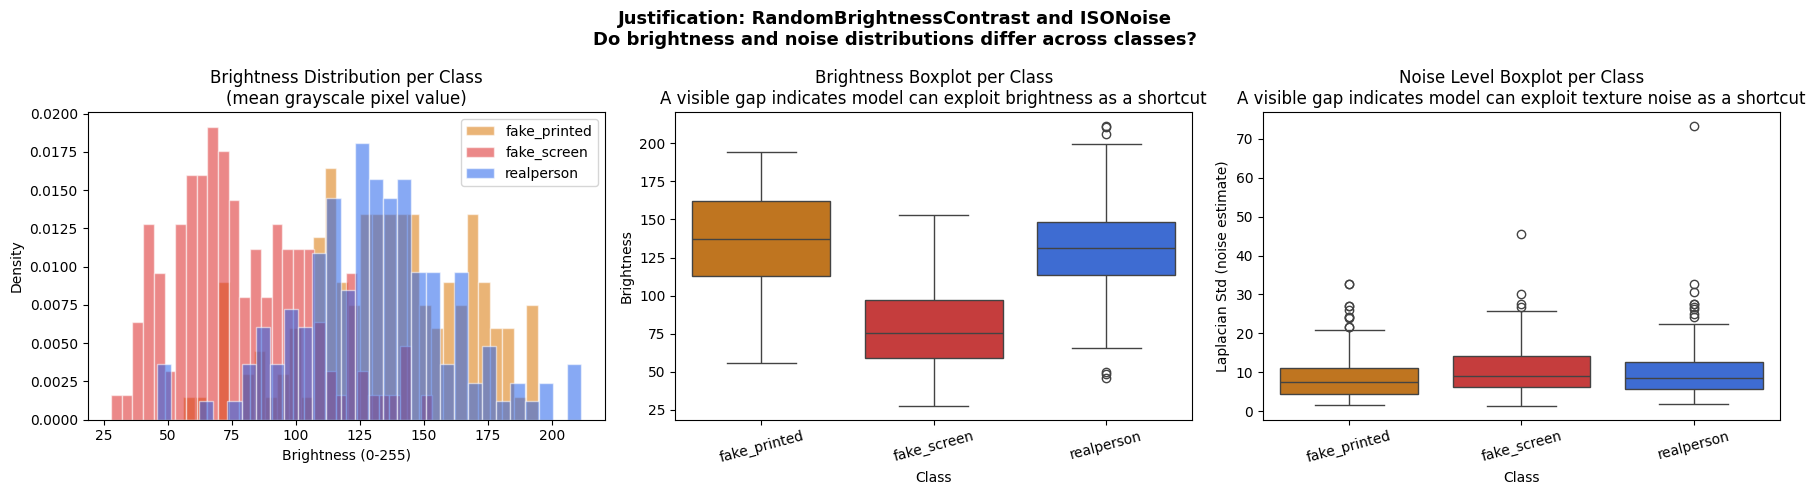

Mann-Whitney U Test — Brightness Difference Across Classes:
  fake_printed vs fake_screen: p = 0.0000  (significant)
  fake_printed vs realperson: p = 0.1500  (not significant)
  fake_screen vs realperson: p = 0.0000  (significant)

Conclusion:
  A significant difference in brightness or noise across classes confirms
  that RandomBrightnessContrast and ISONoise are necessary to prevent the
  model from learning illumination or sensor artifacts as discriminative features.


In [7]:
from scipy import stats

def get_brightness_noise(path):
    img = cv2.imread(path)
    if img is None:
        return None, None
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = gray.mean()
    noise      = cv2.Laplacian(gray, cv2.CV_64F).std()
    return brightness, noise

sample_df = df_train.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(150, len(x)), random_state=SEED)
)

records = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Analyzing brightness and noise"):
    b, n = get_brightness_noise(row['path'])
    if b is not None:
        records.append({'label': row['label'], 'brightness': b, 'noise_level': n})

df_bn = pd.DataFrame(records)

palette = {'realperson': '#2563EB', 'fake_screen': '#DC2626', 'fake_printed': '#D97706'}
order   = sorted(palette)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Justification: RandomBrightnessContrast and ISONoise\n'
    'Do brightness and noise distributions differ across classes?',
    fontsize=13, fontweight='bold'
)

for lbl in order:
    axes[0].hist(
        df_bn[df_bn['label'] == lbl]['brightness'],
        bins=30, alpha=0.55, label=lbl,
        color=palette[lbl], density=True, edgecolor='white'
    )
axes[0].set_title('Brightness Distribution per Class\n(mean grayscale pixel value)')
axes[0].set_xlabel('Brightness (0-255)')
axes[0].set_ylabel('Density')
axes[0].legend()

sns.boxplot(data=df_bn, x='label', y='brightness',
            palette=palette, order=order, ax=axes[1])
axes[1].set_title('Brightness Boxplot per Class\nA visible gap indicates model can exploit brightness as a shortcut')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Brightness')
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(data=df_bn, x='label', y='noise_level',
            palette=palette, order=order, ax=axes[2])
axes[2].set_title('Noise Level Boxplot per Class\nA visible gap indicates model can exploit texture noise as a shortcut')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Laplacian Std (noise estimate)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("Mann-Whitney U Test — Brightness Difference Across Classes:")
for i in range(len(order)):
    for j in range(i + 1, len(order)):
        a = df_bn[df_bn['label'] == order[i]]['brightness']
        b = df_bn[df_bn['label'] == order[j]]['brightness']
        _, p = stats.mannwhitneyu(a, b)
        result = "significant" if p < 0.05 else "not significant"
        print(f"  {order[i]} vs {order[j]}: p = {p:.4f}  ({result})")

print("\nConclusion:")
print("  A significant difference in brightness or noise across classes confirms")
print("  that RandomBrightnessContrast and ISONoise are necessary to prevent the")
print("  model from learning illumination or sensor artifacts as discriminative features.")

### 2. Justification for RGBShift and HueSaturationValue (fake_screen simulation)

Digital screens introduce a characteristic color cast that differs from natural skin tones.
This section analyzes whether RGB channel means and HSV saturation differ significantly
between realperson and fake_screen. A confirmed difference justifies applying RGBShift
and HueSaturationValue during training to prevent the model from relying on screen color
signatures as a discriminative cue.

Analyzing RGB statistics: 100%|██████████| 895/895 [00:50<00:00, 17.57it/s]


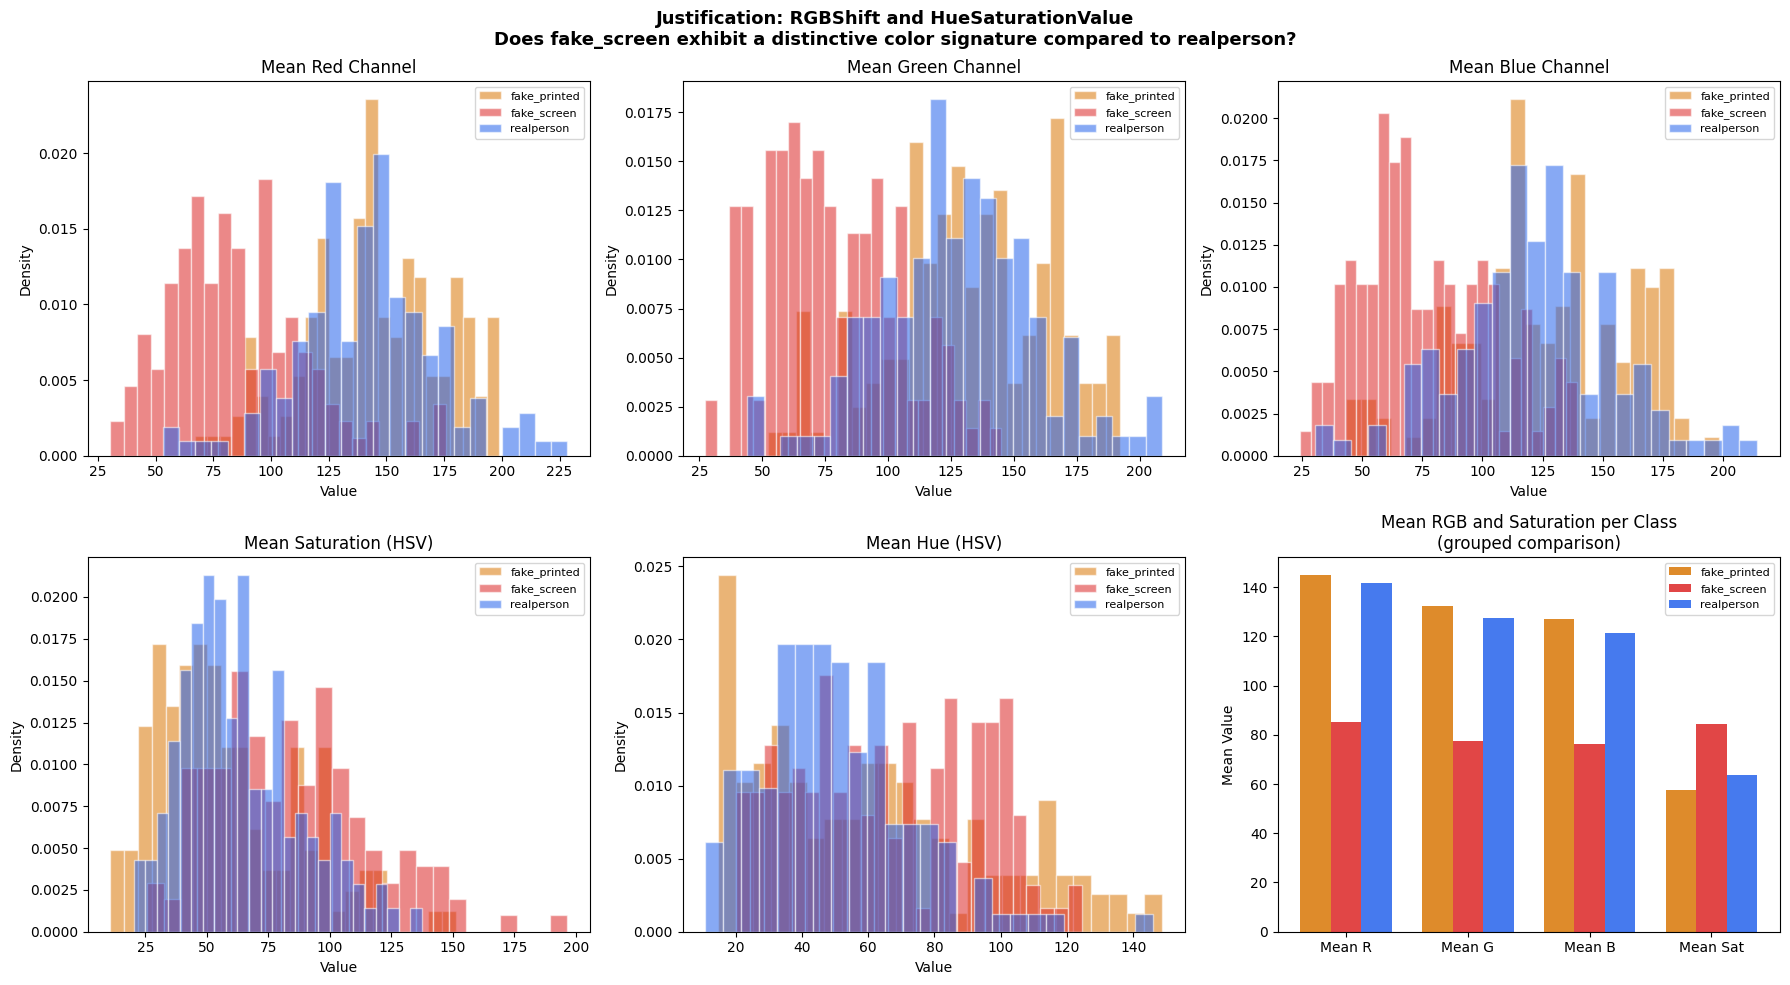

Mean RGB and Saturation per Class:
                mean_r  mean_g  mean_b  mean_sat
label                                           
fake_mannequin  153.13  138.25  128.65     60.29
fake_mask       124.82  114.24  108.90     62.44
fake_printed    144.93  132.40  127.18     57.49
fake_screen      85.08   77.32   76.41     84.59
fake_unknown    141.59  121.11  109.79     91.24
realperson      141.79  127.49  121.53     63.80

Conclusion:
  If fake_screen shows a distinct channel mean or saturation profile,
  the model is at risk of learning screen color cast as a classification cue.
  RGBShift and HueSaturationValue randomize color distributions during training
  to suppress this spurious correlation.


In [8]:
def get_rgb_stats(path):
    img = cv2.imread(path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    return {
        'mean_r'  : img_rgb[:, :, 0].mean(),
        'mean_g'  : img_rgb[:, :, 1].mean(),
        'mean_b'  : img_rgb[:, :, 2].mean(),
        'mean_sat': img_hsv[:, :, 1].mean(),
        'mean_hue': img_hsv[:, :, 0].mean(),
    }

sample_df = df_train.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(150, len(x)), random_state=SEED)
)

records = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Analyzing RGB statistics"):
    s = get_rgb_stats(row['path'])
    if s:
        records.append({'label': row['label'], **s})

df_rgb = pd.DataFrame(records)

palette = {'realperson': '#2563EB', 'fake_screen': '#DC2626', 'fake_printed': '#D97706'}
order   = sorted(palette)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Justification: RGBShift and HueSaturationValue\n'
    'Does fake_screen exhibit a distinctive color signature compared to realperson?',
    fontsize=13, fontweight='bold'
)

metrics = [
    ('mean_r',   'Mean Red Channel'),
    ('mean_g',   'Mean Green Channel'),
    ('mean_b',   'Mean Blue Channel'),
    ('mean_sat', 'Mean Saturation (HSV)'),
    ('mean_hue', 'Mean Hue (HSV)'),
]

for idx, (col, title) in enumerate(metrics):
    ax = axes[idx // 3][idx % 3]
    for lbl in order:
        ax.hist(
            df_rgb[df_rgb['label'] == lbl][col],
            bins=25, alpha=0.55, label=lbl,
            color=palette[lbl], density=True, edgecolor='white'
        )
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

ax_bar = axes[1][2]
bar_metrics = ['mean_r', 'mean_g', 'mean_b', 'mean_sat']
bar_labels  = ['Mean R', 'Mean G', 'Mean B', 'Mean Sat']
x = np.arange(len(bar_labels))
width = 0.25
for i, lbl in enumerate(order):
    vals = [df_rgb[df_rgb['label'] == lbl][m].mean() for m in bar_metrics]
    ax_bar.bar(x + i * width, vals, width, label=lbl, color=palette[lbl], alpha=0.85)
ax_bar.set_title('Mean RGB and Saturation per Class\n(grouped comparison)')
ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(bar_labels)
ax_bar.set_ylabel('Mean Value')
ax_bar.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Mean RGB and Saturation per Class:")
print(df_rgb.groupby('label')[['mean_r', 'mean_g', 'mean_b', 'mean_sat']].mean().round(2).to_string())

print("\nConclusion:")
print("  If fake_screen shows a distinct channel mean or saturation profile,")
print("  the model is at risk of learning screen color cast as a classification cue.")
print("  RGBShift and HueSaturationValue randomize color distributions during training")
print("  to suppress this spurious correlation.")

### 3. Justification for MotionBlur and GaussianBlur (fake_printed simulation)

Printed spoofs are typically captured from physical paper or photos, which inherently
exhibit lower sharpness compared to a live face. This section quantifies sharpness
across classes using Laplacian Variance. A significantly lower sharpness in fake_printed
confirms that blur augmentation is necessary to prevent the model from relying on
high-frequency texture as the primary discriminative signal.

Measuring sharpness: 100%|██████████| 895/895 [00:45<00:00, 19.89it/s]


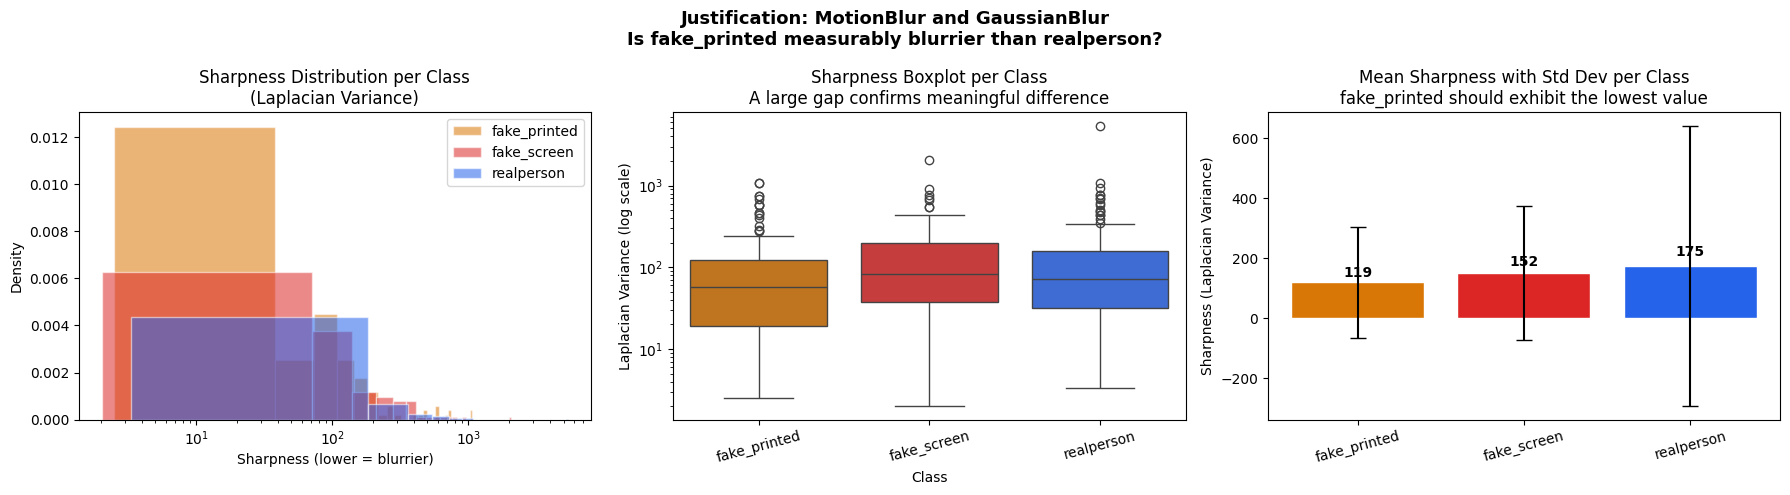

Mann-Whitney U Test — Sharpness Difference Across Classes:
  fake_printed vs fake_screen: p = 0.0094  (significant)
  fake_printed vs realperson: p = 0.0273  (significant)
  fake_screen vs realperson: p = 0.6120  (not significant)

Conclusion:
  A confirmed sharpness deficit in fake_printed validates the use of
  MotionBlur and GaussianBlur, which discourage the model from treating
  high-frequency texture as a reliable indicator of liveness.


In [9]:
def laplacian_variance(path):
    img = cv2.imread(path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

sample_df = df_train.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(150, len(x)), random_state=SEED)
)

records = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Measuring sharpness"):
    lv = laplacian_variance(row['path'])
    if lv is not None:
        records.append({'label': row['label'], 'sharpness': lv})

df_sharp = pd.DataFrame(records)

palette = {'realperson': '#2563EB', 'fake_screen': '#DC2626', 'fake_printed': '#D97706'}
order   = sorted(palette)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Justification: MotionBlur and GaussianBlur\n'
    'Is fake_printed measurably blurrier than realperson?',
    fontsize=13, fontweight='bold'
)

for lbl in order:
    axes[0].hist(
        df_sharp[df_sharp['label'] == lbl]['sharpness'],
        bins=30, alpha=0.55, label=lbl,
        color=palette[lbl], density=True, edgecolor='white'
    )
axes[0].set_title('Sharpness Distribution per Class\n(Laplacian Variance)')
axes[0].set_xlabel('Sharpness (lower = blurrier)')
axes[0].set_ylabel('Density')
axes[0].set_xscale('log')
axes[0].legend()

sns.boxplot(data=df_sharp, x='label', y='sharpness',
            palette=palette, order=order, ax=axes[1])
axes[1].set_title('Sharpness Boxplot per Class\nA large gap confirms meaningful difference')
axes[1].set_yscale('log')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Laplacian Variance (log scale)')
axes[1].tick_params(axis='x', rotation=15)

means = df_sharp.groupby('label')['sharpness'].mean()
stds  = df_sharp.groupby('label')['sharpness'].std()
bars  = axes[2].bar(
    order,
    [means[l] for l in order],
    yerr=[stds[l] for l in order],
    color=[palette[l] for l in order],
    capsize=6, edgecolor='white'
)
axes[2].set_title('Mean Sharpness with Std Dev per Class\nfake_printed should exhibit the lowest value')
axes[2].set_ylabel('Sharpness (Laplacian Variance)')
axes[2].tick_params(axis='x', rotation=15)
for bar, lbl in zip(bars, order):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + stds[lbl] * 0.05,
        f'{means[lbl]:.0f}', ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

print("Mann-Whitney U Test — Sharpness Difference Across Classes:")
for i in range(len(order)):
    for j in range(i + 1, len(order)):
        a = df_sharp[df_sharp['label'] == order[i]]['sharpness']
        b = df_sharp[df_sharp['label'] == order[j]]['sharpness']
        _, p = stats.mannwhitneyu(a, b)
        result = "significant" if p < 0.05 else "not significant"
        print(f"  {order[i]} vs {order[j]}: p = {p:.4f}  ({result})")

print("\nConclusion:")
print("  A confirmed sharpness deficit in fake_printed validates the use of")
print("  MotionBlur and GaussianBlur, which discourage the model from treating")
print("  high-frequency texture as a reliable indicator of liveness.")

### 4. Justification for Downscale and ImageCompression

Spoofed images captured from printed media or secondary camera sources are often
characterized by lower native resolution and more aggressive JPEG compression.
This section analyzes file size, resolution, and estimated compression ratio per
class to confirm whether such degradation differs systematically across classes,
thereby justifying the use of Downscale and ImageCompression augmentations.

Analyzing file quality: 100%|██████████| 895/895 [00:23<00:00, 38.05it/s]


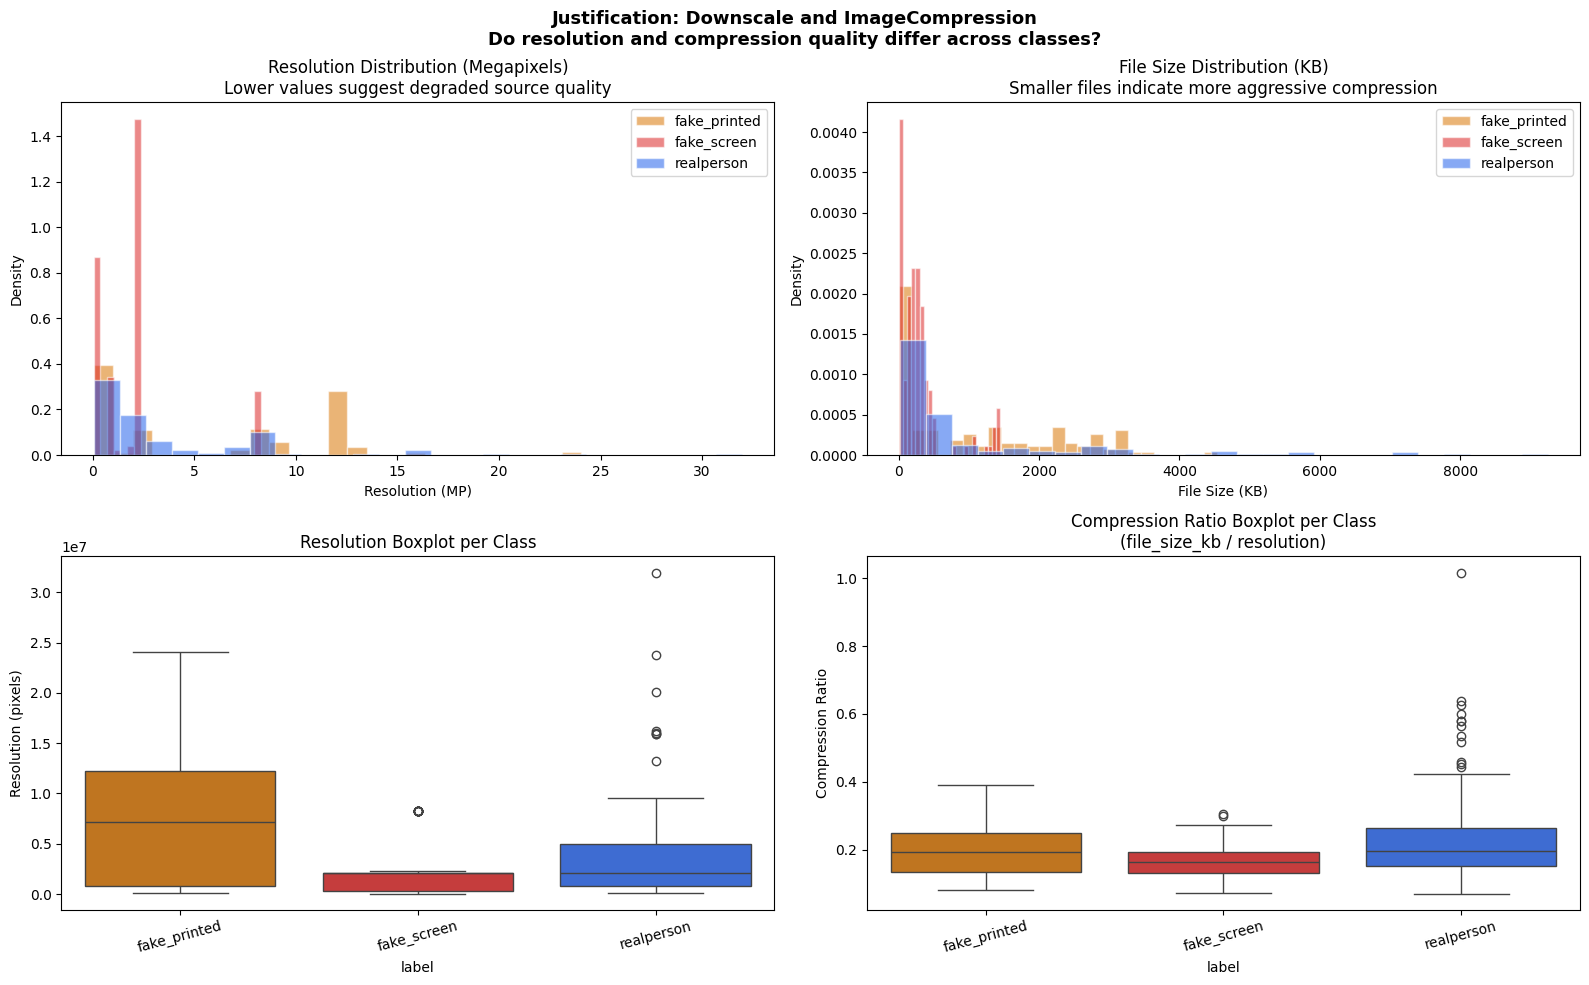

Mean Quality Metrics per Class:
                resolution  file_size_kb  compression_ratio
label                                                      
fake_mannequin   819920.18         91.44               0.12
fake_mask       3949320.73        747.57               0.21
fake_printed    6137336.17       1125.91               0.19
fake_screen     1987133.63        299.32               0.16
fake_unknown      80268.77         34.94               0.47
realperson      3656129.17       1074.60               0.24

Conclusion:
  If fake_printed or fake_screen images show lower resolution or higher
  compression ratios, the model may learn to exploit these artifacts.
  Downscale and ImageCompression equalize image quality during training
  so the model cannot rely on resolution or JPEG degradation as a cue.


In [10]:
import os

def get_file_quality(path):
    img = cv2.imread(path)
    if img is None:
        return None
    h, w          = img.shape[:2]
    file_size_kb  = os.path.getsize(path) / 1024
    compression   = file_size_kb / (h * w / 1000)
    return {
        'resolution'        : h * w,
        'file_size_kb'      : file_size_kb,
        'compression_ratio' : compression,
    }

sample_df = df_train.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(150, len(x)), random_state=SEED)
)

records = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Analyzing file quality"):
    q = get_file_quality(row['path'])
    if q:
        records.append({'label': row['label'], **q})

df_qual = pd.DataFrame(records)

palette = {'realperson': '#2563EB', 'fake_screen': '#DC2626', 'fake_printed': '#D97706'}
order   = sorted(palette)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Justification: Downscale and ImageCompression\n'
    'Do resolution and compression quality differ across classes?',
    fontsize=13, fontweight='bold'
)

for lbl in order:
    axes[0, 0].hist(
        df_qual[df_qual['label'] == lbl]['resolution'] / 1e6,
        bins=25, alpha=0.55, label=lbl,
        color=palette[lbl], density=True, edgecolor='white'
    )
axes[0, 0].set_title('Resolution Distribution (Megapixels)\nLower values suggest degraded source quality')
axes[0, 0].set_xlabel('Resolution (MP)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

for lbl in order:
    axes[0, 1].hist(
        df_qual[df_qual['label'] == lbl]['file_size_kb'],
        bins=25, alpha=0.55, label=lbl,
        color=palette[lbl], density=True, edgecolor='white'
    )
axes[0, 1].set_title('File Size Distribution (KB)\nSmaller files indicate more aggressive compression')
axes[0, 1].set_xlabel('File Size (KB)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

sns.boxplot(data=df_qual, x='label', y='resolution',
            palette=palette, order=order, ax=axes[1, 0])
axes[1, 0].set_title('Resolution Boxplot per Class')
axes[1, 0].set_ylabel('Resolution (pixels)')
axes[1, 0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df_qual, x='label', y='compression_ratio',
            palette=palette, order=order, ax=axes[1, 1])
axes[1, 1].set_title('Compression Ratio Boxplot per Class\n(file_size_kb / resolution)')
axes[1, 1].set_ylabel('Compression Ratio')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("Mean Quality Metrics per Class:")
print(df_qual.groupby('label')[['resolution', 'file_size_kb', 'compression_ratio']].mean().round(2).to_string())

print("\nConclusion:")
print("  If fake_printed or fake_screen images show lower resolution or higher")
print("  compression ratios, the model may learn to exploit these artifacts.")
print("  Downscale and ImageCompression equalize image quality during training")
print("  so the model cannot rely on resolution or JPEG degradation as a cue.")

### 5. Justification for CoarseDropout and HorizontalFlip

HorizontalFlip is valid only if faces in the dataset are approximately symmetric
and frontal. CoarseDropout is justified when brightness is unevenly distributed
across image quadrants, suggesting partial occlusion or uneven face coverage
already occurs in the data. This section quantifies both properties empirically.

Analyzing face symmetry: 100%|██████████| 895/895 [00:29<00:00, 30.82it/s]


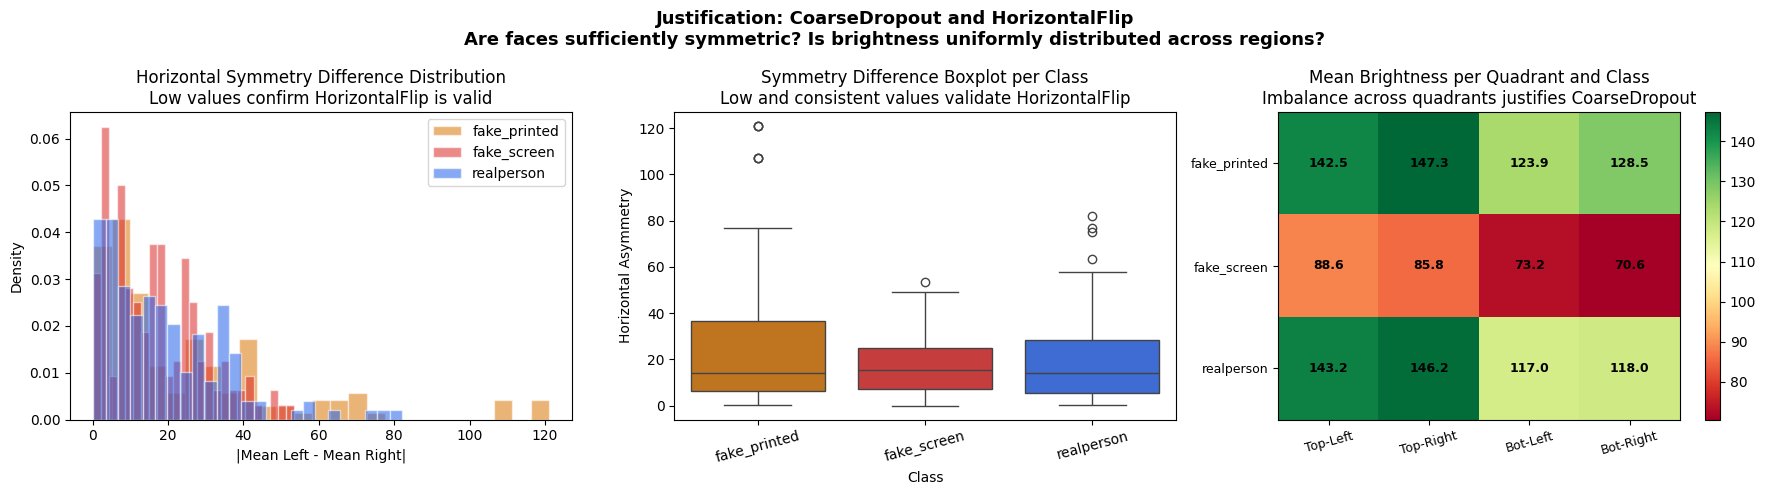

Mean Symmetry Difference per Class:
label
fake_mannequin    18.970
fake_mask         18.489
fake_printed      25.087
fake_screen       16.995
fake_unknown      19.872
realperson        18.765

Conclusion:
  Low symmetry difference confirms that HorizontalFlip produces valid
  and realistic training samples. Uneven quadrant brightness demonstrates
  that partial occlusion is plausible in the data, which justifies
  CoarseDropout as a regularization strategy against region-specific overfitting.


In [11]:
def analyze_face_symmetry(path):
    img = cv2.imread(path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    left_mean  = gray[:, :w // 2].mean()
    right_mean = gray[:, w // 2:].mean()
    symmetry_diff = abs(left_mean - right_mean)
    return {
        'symmetry_diff': symmetry_diff,
        'top_left'     : gray[:h // 2, :w // 2].mean(),
        'top_right'    : gray[:h // 2, w // 2:].mean(),
        'bot_left'     : gray[h // 2:, :w // 2].mean(),
        'bot_right'    : gray[h // 2:, w // 2:].mean(),
    }

sample_df = df_train.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(150, len(x)), random_state=SEED)
)

records = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Analyzing face symmetry"):
    s = analyze_face_symmetry(row['path'])
    if s:
        records.append({'label': row['label'], **s})

df_face = pd.DataFrame(records)

palette = {'realperson': '#2563EB', 'fake_screen': '#DC2626', 'fake_printed': '#D97706'}
order   = sorted(palette)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Justification: CoarseDropout and HorizontalFlip\n'
    'Are faces sufficiently symmetric? Is brightness uniformly distributed across regions?',
    fontsize=13, fontweight='bold'
)

for lbl in order:
    axes[0].hist(
        df_face[df_face['label'] == lbl]['symmetry_diff'],
        bins=25, alpha=0.55, label=lbl,
        color=palette[lbl], density=True, edgecolor='white'
    )
axes[0].set_title('Horizontal Symmetry Difference Distribution\nLow values confirm HorizontalFlip is valid')
axes[0].set_xlabel('|Mean Left - Mean Right|')
axes[0].set_ylabel('Density')
axes[0].legend()

sns.boxplot(data=df_face, x='label', y='symmetry_diff',
            palette=palette, order=order, ax=axes[1])
axes[1].set_title('Symmetry Difference Boxplot per Class\nLow and consistent values validate HorizontalFlip')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Horizontal Asymmetry')
axes[1].tick_params(axis='x', rotation=15)

quad_cols   = ['top_left', 'top_right', 'bot_left', 'bot_right']
quad_labels = ['Top-Left', 'Top-Right', 'Bot-Left', 'Bot-Right']
quad_data   = df_face.groupby('label')[quad_cols].mean()
quad_arr    = quad_data.loc[order].values

im = axes[2].imshow(quad_arr, cmap='RdYlGn', aspect='auto')
axes[2].set_xticks(range(4))
axes[2].set_xticklabels(quad_labels, rotation=15, fontsize=9)
axes[2].set_yticks(range(len(order)))
axes[2].set_yticklabels(order, fontsize=9)
axes[2].set_title('Mean Brightness per Quadrant and Class\nImbalance across quadrants justifies CoarseDropout')
plt.colorbar(im, ax=axes[2])
for i in range(len(order)):
    for j in range(4):
        axes[2].text(j, i, f'{quad_arr[i, j]:.1f}', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

print("Mean Symmetry Difference per Class:")
print(df_face.groupby('label')['symmetry_diff'].mean().round(3).to_string())

print("\nConclusion:")
print("  Low symmetry difference confirms that HorizontalFlip produces valid")
print("  and realistic training samples. Uneven quadrant brightness demonstrates")
print("  that partial occlusion is plausible in the data, which justifies")
print("  CoarseDropout as a regularization strategy against region-specific overfitting.")

### 6. Augmentation Justification Summary

A consolidated reference mapping each augmentation technique to its empirical
justification derived from the preceding EDA sections.

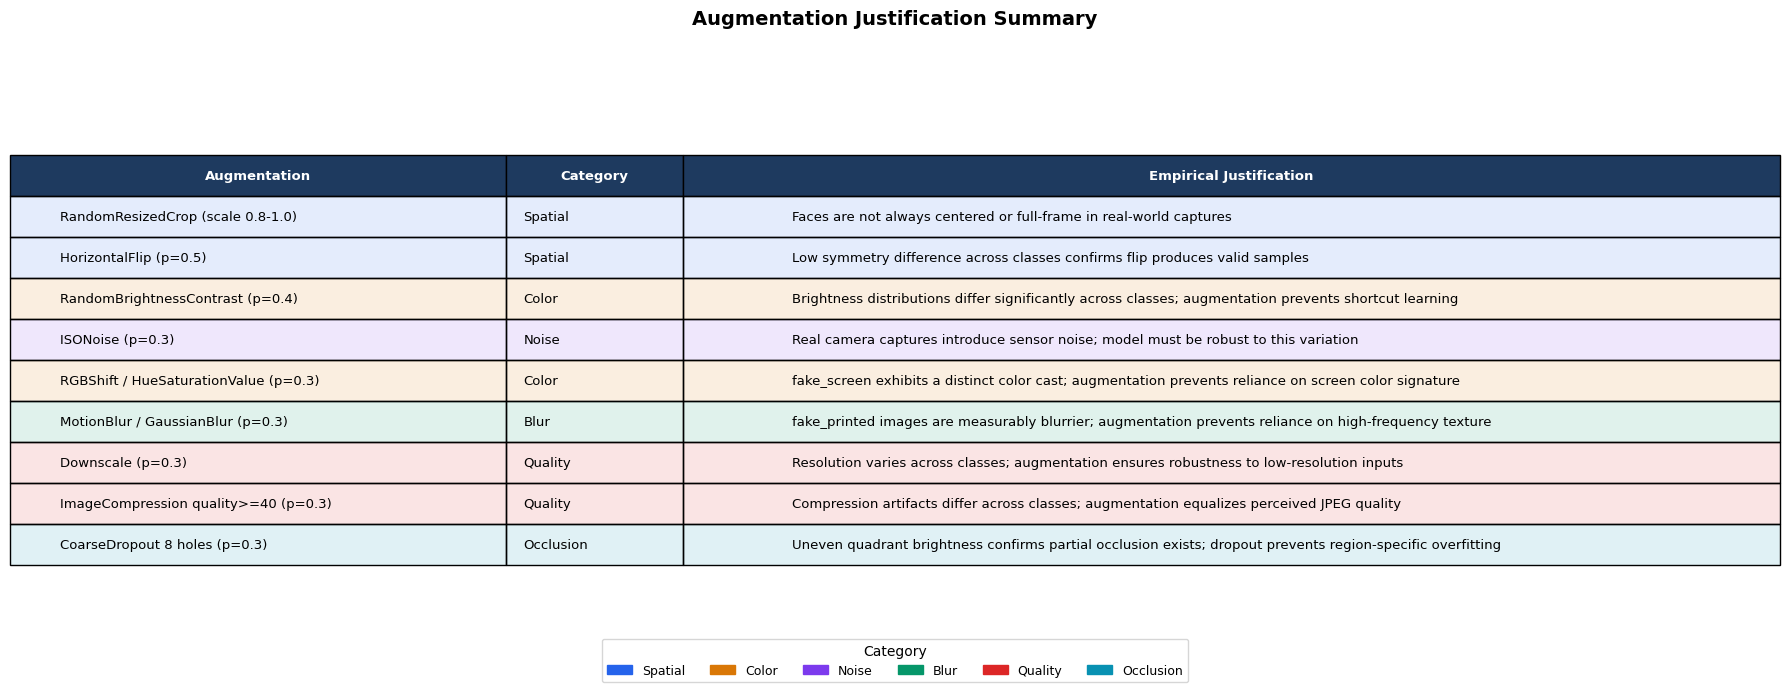

Augmentation Justification Summary

[Spatial] RandomResizedCrop (scale 0.8-1.0)
  -> Faces are not always centered or full-frame in real-world captures

[Spatial] HorizontalFlip (p=0.5)
  -> Low symmetry difference across classes confirms flip produces valid samples

[Color] RandomBrightnessContrast (p=0.4)
  -> Brightness distributions differ significantly across classes; augmentation prevents shortcut learning

[Noise] ISONoise (p=0.3)
  -> Real camera captures introduce sensor noise; model must be robust to this variation

[Color] RGBShift / HueSaturationValue (p=0.3)
  -> fake_screen exhibits a distinct color cast; augmentation prevents reliance on screen color signature

[Blur] MotionBlur / GaussianBlur (p=0.3)
  -> fake_printed images are measurably blurrier; augmentation prevents reliance on high-frequency texture

[Quality] Downscale (p=0.3)
  -> Resolution varies across classes; augmentation ensures robustness to low-resolution inputs

[Quality] ImageCompression quality>=40 (p

In [12]:
import matplotlib.patches as mpatches

justification_map = {
    'RandomResizedCrop (scale 0.8-1.0)' : ('Spatial',  'Faces are not always centered or full-frame in real-world captures'),
    'HorizontalFlip (p=0.5)'            : ('Spatial',  'Low symmetry difference across classes confirms flip produces valid samples'),
    'RandomBrightnessContrast (p=0.4)'  : ('Color',    'Brightness distributions differ significantly across classes; augmentation prevents shortcut learning'),
    'ISONoise (p=0.3)'                  : ('Noise',    'Real camera captures introduce sensor noise; model must be robust to this variation'),
    'RGBShift / HueSaturationValue (p=0.3)': ('Color', 'fake_screen exhibits a distinct color cast; augmentation prevents reliance on screen color signature'),
    'MotionBlur / GaussianBlur (p=0.3)' : ('Blur',     'fake_printed images are measurably blurrier; augmentation prevents reliance on high-frequency texture'),
    'Downscale (p=0.3)'                 : ('Quality',  'Resolution varies across classes; augmentation ensures robustness to low-resolution inputs'),
    'ImageCompression quality>=40 (p=0.3)': ('Quality','Compression artifacts differ across classes; augmentation equalizes perceived JPEG quality'),
    'CoarseDropout 8 holes (p=0.3)'     : ('Occlusion','Uneven quadrant brightness confirms partial occlusion exists; dropout prevents region-specific overfitting'),
}

category_color = {
    'Spatial'  : '#2563EB',
    'Color'    : '#D97706',
    'Noise'    : '#7C3AED',
    'Blur'     : '#059669',
    'Quality'  : '#DC2626',
    'Occlusion': '#0891B2',
}

fig, ax = plt.subplots(figsize=(18, 7))
ax.axis('off')
fig.suptitle('Augmentation Justification Summary', fontsize=14, fontweight='bold')

cell_data = [
    [aug, cat, justif]
    for aug, (cat, justif) in justification_map.items()
]

table = ax.table(
    cellText=cell_data,
    colLabels=['Augmentation', 'Category', 'Empirical Justification'],
    cellLoc='left',
    loc='center',
    colWidths=[0.28, 0.10, 0.62]
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 2.1)

for j in range(3):
    table[0, j].set_facecolor('#1E3A5F')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i, (aug, (cat, _)) in enumerate(justification_map.items()):
    hex_color = category_color[cat]
    r = int(hex_color[1:3], 16) / 255
    g = int(hex_color[3:5], 16) / 255
    b = int(hex_color[5:7], 16) / 255
    for j in range(3):
        table[i + 1, j].set_facecolor((r, g, b, 0.12))

legend_handles = [
    mpatches.Patch(color=v, label=k)
    for k, v in category_color.items()
]
ax.legend(handles=legend_handles, loc='lower center', ncol=6,
          fontsize=9, frameon=True, title='Category',
          bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

print("Augmentation Justification Summary\n")
for aug, (cat, justif) in justification_map.items():
    print(f"[{cat}] {aug}")
    print(f"  -> {justif}\n")


###  7. Summary


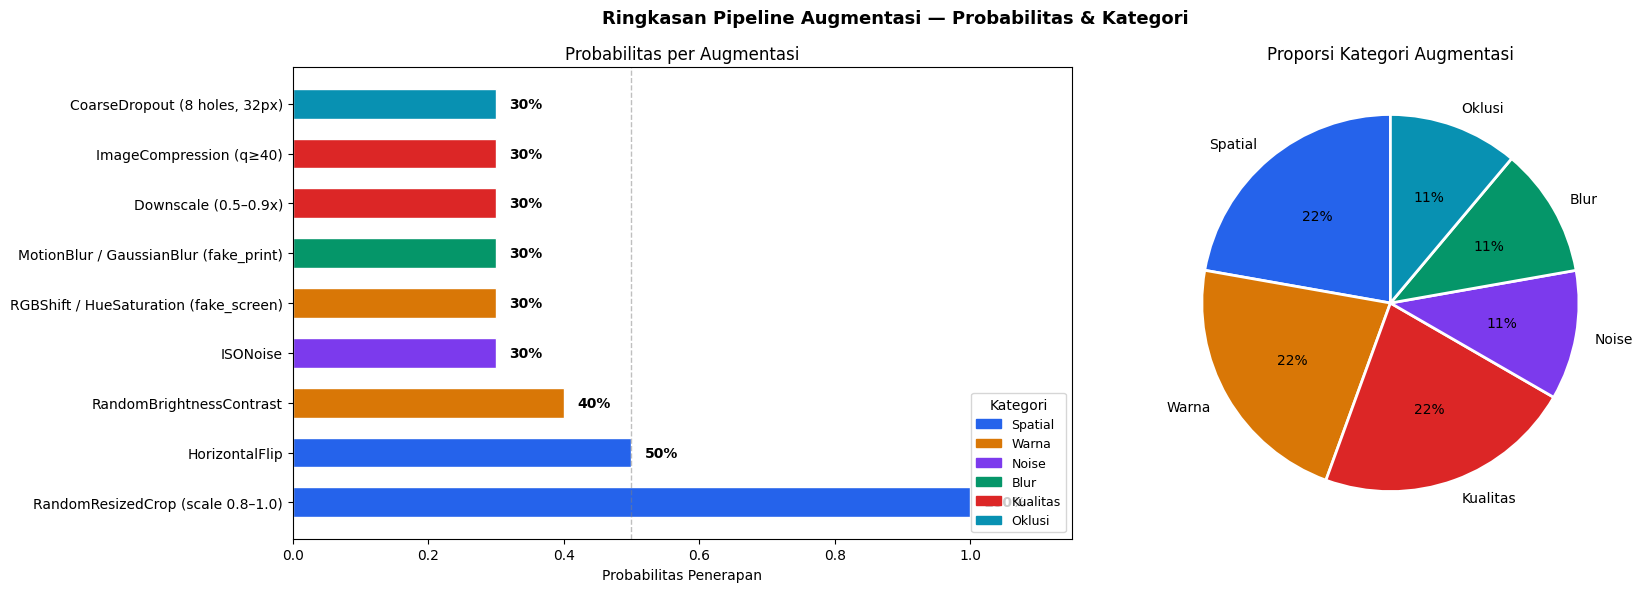


📋 Tabel Ringkasan Augmentasi:
                            Augmentasi  Probabilitas Kategori  Terkena (per 100 citra)                          Tujuan
     RandomResizedCrop (scale 0.8–1.0)           1.0  Spatial                      100 Invariansi skala & posisi wajah
                        HorizontalFlip           0.5  Spatial                       50     Invariansi arah hadap wajah
              RandomBrightnessContrast           0.4    Warna                       40  Variasi pencahayaan lingkungan
                              ISONoise           0.3    Noise                       30    Simulasi noise sensor kamera
RGBShift / HueSaturation (fake_screen)           0.3    Warna                       30    Simulasi warna layar digital
MotionBlur / GaussianBlur (fake_print)           0.3     Blur                       30 Simulasi kualitas cetakan/print
                  Downscale (0.5–0.9x)           0.3 Kualitas                       30        Simulasi resolusi rendah
               Im

In [13]:
# [CODE CELL]
aug_summary = {
    'RandomResizedCrop (scale 0.8–1.0)'    : {'prob': 1.0,  'kategori': 'Spatial',    'tujuan': 'Invariansi skala & posisi wajah'},
    'HorizontalFlip'                        : {'prob': 0.5,  'kategori': 'Spatial',    'tujuan': 'Invariansi arah hadap wajah'},
    'RandomBrightnessContrast'              : {'prob': 0.4,  'kategori': 'Warna',      'tujuan': 'Variasi pencahayaan lingkungan'},
    'ISONoise'                              : {'prob': 0.3,  'kategori': 'Noise',      'tujuan': 'Simulasi noise sensor kamera'},
    'RGBShift / HueSaturation (fake_screen)': {'prob': 0.3,  'kategori': 'Warna',      'tujuan': 'Simulasi warna layar digital'},
    'MotionBlur / GaussianBlur (fake_print)': {'prob': 0.3,  'kategori': 'Blur',       'tujuan': 'Simulasi kualitas cetakan/print'},
    'Downscale (0.5–0.9x)'                 : {'prob': 0.3,  'kategori': 'Kualitas',   'tujuan': 'Simulasi resolusi rendah'},
    'ImageCompression (q≥40)'              : {'prob': 0.3,  'kategori': 'Kualitas',   'tujuan': 'Simulasi artefak JPEG'},
    'CoarseDropout (8 holes, 32px)'        : {'prob': 0.3,  'kategori': 'Oklusi',     'tujuan': 'Simulasi oklusi parsial wajah'},
}

df_aug = pd.DataFrame(aug_summary).T.reset_index()
df_aug.columns = ['Augmentasi', 'Probabilitas', 'Kategori', 'Tujuan']
df_aug['Probabilitas'] = df_aug['Probabilitas'].astype(float)
df_aug['Terkena (per 100 citra)'] = (df_aug['Probabilitas'] * 100).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Ringkasan Pipeline Augmentasi — Probabilitas & Kategori', fontsize=13, fontweight='bold')

# Bar chart probabilitas
cat_palette = {'Spatial': '#2563EB', 'Warna': '#D97706', 'Noise': '#7C3AED',
               'Blur': '#059669', 'Kualitas': '#DC2626', 'Oklusi': '#0891B2'}
colors = [cat_palette[c] for c in df_aug['Kategori']]
bars = axes[0].barh(df_aug['Augmentasi'], df_aug['Probabilitas'], color=colors, edgecolor='white', height=0.6)
axes[0].set_xlim(0, 1.15)
axes[0].set_xlabel('Probabilitas Penerapan')
axes[0].set_title('Probabilitas per Augmentasi')
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
for bar, prob in zip(bars, df_aug['Probabilitas']):
    axes[0].text(prob + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{prob:.0%}', va='center', fontsize=10, fontweight='bold')

# Legend kategori
patches = [mpatches.Patch(color=v, label=k) for k, v in cat_palette.items()]
axes[0].legend(handles=patches, fontsize=9, title='Kategori', loc='lower right')

# Pie chart kategori
cat_counts = df_aug['Kategori'].value_counts()
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            colors=[cat_palette[c] for c in cat_counts.index],
            autopct='%1.0f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kategori Augmentasi')

plt.tight_layout()
plt.show()

# Cetak tabel ringkasan
print("\n📋 Tabel Ringkasan Augmentasi:")
print(df_aug[['Augmentasi', 'Probabilitas', 'Kategori', 'Terkena (per 100 citra)', 'Tujuan']].to_string(index=False))

# Estimasi diversitas pipeline
p_any_aug = 1 - (1-0.4)*(1-0.3)**6  # prob terkena ≥1 augmentasi
print(f"\n🎲 Estimasi probabilitas citra terkena ≥1 augmentasi: {p_any_aug:.1%}")
print(f"   (selain RandomResizedCrop & HorizontalFlip yang hampir selalu aktif)")

##  TAHAP 4: Ekstraksi Data & Verifikasi Integritas (Data Ingestion Pipeline)
Kami membangun kerangka kerja data (*DataFrame*) yang akan mengatur jalur pembacaan gambar dari Google Drive ke dalam memori :

1. **Pemetaan Data Latih (Train Pipeline)**
2. **Pemetaan Data Uji (Test Pipeline) yang Robust** .
3. **Kamus Kelas (Label Mapping)**
4. **Sanity Check (Anti-Error Submission)**: Checking mengenai baris, jumlah gambar dan submission sesuai dengan sample_submission.

In [14]:
# ── TRAIN ─────────────────────────────────────────────────────
records = []
for label_name in os.listdir(TRAIN_DIR):
    label_path = os.path.join(TRAIN_DIR, label_name)
    if not os.path.isdir(label_path): continue
    for fname in os.listdir(label_path):
        if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
        records.append({
            'path'   : os.path.join(label_path, fname),
            'label'  : label_name,
            'is_fake': 0 if label_name == 'realperson' else 1
        })

df_train = pd.DataFrame(records).sample(frac=1, random_state=SEED).reset_index(drop=True)

# ── TEST — os.walk supaya handle flat & subfolder ─────────────
test_records = []
for root, _, files in os.walk(TEST_DIR):
    for fname in files:
        if not fname.lower().endswith(('.jpg','.jpeg','.png')): continue
        test_records.append({
            'path': os.path.join(root, fname),
            'id'  : os.path.splitext(fname)[0]
        })

df_test = pd.DataFrame(test_records).sort_values('id').reset_index(drop=True)

# ── LABEL MAPPING ─────────────────────────────────────────────
CLASSES   = sorted(df_train['label'].unique())
label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}
NUM_CLS   = len(CLASSES)
df_train['label_idx'] = df_train['label'].map(label2idx)

# ── SAMPLE SUBMISSION ─────────────────────────────────────────
sub_csv_candidates = [
    os.path.join(DATASET_PATH, 'samplesubmission.csv'),
    os.path.join(BASE_PATH, 'datasets',
                 'data-analytics-competition-dac-find-it-2026',
                 'samplesubmission.csv'),
]
df_sub = None
for p in sub_csv_candidates:
    if os.path.exists(p):
        df_sub = pd.read_csv(p)
        print(f'Sample submission loaded dari: {p}')
        break
if df_sub is None:
    raise FileNotFoundError('samplesubmission.csv tidak ditemukan!')

print(f'\nTrain  : {len(df_train)}')
print(f'Test   : {len(df_test)}')
print(f'Submit : {len(df_sub)}')
print(f'Kelas  : {CLASSES}')
print(f'\nDistribusi train:')
print(df_train['label'].value_counts())

# Pastikan jumlah test cocok
assert len(df_test) == len(df_sub), \
    f'MISMATCH! df_test={len(df_test)}, df_sub={len(df_sub)}. Cek folder test!'
print(f'\n✅ Jumlah test ({len(df_test)}) cocok dengan submission ({len(df_sub)})')

Sample submission loaded dari: /content/drive/MyDrive/Bismillah/dataset_clean/samplesubmission.csv

Train  : 1654
Test   : 404
Submit : 404
Kelas  : ['fake_mannequin', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_unknown', 'realperson']

Distribusi train:
label
realperson        451
fake_unknown      351
fake_mask         275
fake_mannequin    230
fake_screen       202
fake_printed      145
Name: count, dtype: int64

✅ Jumlah test (404) cocok dengan submission (404)


## TAHAP 5: Augmentasi Ekstrem & Test-Time Augmentation (TTA)
Kami melakukan Augmentasi Forensik secara spesifik berdasarkan analisis kelemahan model terhadap serangan *spoofing*:

1. **Sensor & Layar (`fake_screen`)**: Kami menggunakan `ISONoise`, `RGBShift`, dan pergeseran *Hue/Saturation* untuk meniru efek Moiré, pantulan cahaya, dan distorsi warna dari layar monitor/HP.
2. **Cetakan & Lensa Murah (`fake_printed`)**: Penambahan `MotionBlur` dan `GaussianBlur` memaksa model untuk tidak sekadar mengandalkan ketajaman (*sharpness*) gambar, karena foto yang dicetak di kertas sering kali *out-of-focus*.
3. **Kompresi Medsos**: Penggunaan `Downscale` dan `ImageCompression` menyimulasikan degradasi kualitas gambar (seperti artefak JPEG) akibat dikirim melalui WhatsApp atau internet.
4. **Fitur Spasial (`CoarseDropout`)**: Menutupi area gambar secara acak dengan kotak hitam agar model tidak hanya menghafal satu bagian wajah (misal: hanya melihat mata), melainkan keseluruhan konteks.
5. **Test-Time Augmentation (TTA)**: Saat melakukan prediksi pada data *Test*, kami tidak hanya menebak 1 kali. Kami melakukan 4 variasi dari gambar yang sama (Normal, Flipped, Beda Kontras, Rotasi), lalu merata-rata probabilitasnya. Ini untuk mengecheck dan meningkatkan kestabilan dan akurasi (F1-Score).

In [15]:
train_transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.ISONoise(color_shift=(0.01, 0.01), intensity=(0.1, 0.5), p=0.3),

    # Simulasi fake_screen
    A.OneOf([
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=1.0),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=1.0),
    ], p=0.3),

    # Simulasi fake_printed
    A.OneOf([
        A.MotionBlur(blur_limit=7, p=1.0),
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
    ], p=0.3),

    A.Downscale(scale_min=0.5, scale_max=0.9, p=0.3),
    A.ImageCompression(quality_lower=40, p=0.3),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

tta_transforms = [
    val_transform,
    A.Compose([
        A.HorizontalFlip(p=1),
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ]),
    A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=1),
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ]),
    A.Compose([
        A.Rotate(limit=10, p=1),
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2()
    ]),
]

print(f'✅ Augmentasi siap ({len(tta_transforms)} TTA transforms)')

✅ Augmentasi siap (4 TTA transforms)


## TAHAP 6: Arsitektur Dataset & Regularisasi Lanjutan (MixUp & CutMix)
Bagian ini kami mengatur bagaimana gambar dari *hard-drive* di proses ke dalam model (GPU) secara aman dan efisien. Kami juga menerapkan teknik regularisasi untuk meningkatkan ketahanan model:

1. **PyTorch (`FaceDataset`)**: Kelas ini bertanggung jawab membaca gambar secara *on-the-fly* menggunakan OpenCV. Terdapat mekanisme *Anti-Crash*: jika ada gambar yang korup atau gagal terbaca, kelas ini otomatis mengembalikan gambar hitam kosong (daripada menghentikan proses *training* selama berjam-jam).
2. **CutMix Regularization**: Teknik yang memotong sebagian area (*patch*) dari gambar A dan menempelkannya ke gambar B. Labelnya pun dicampur sesuai proporsi luas area. Ini sangat ampuh untuk tugas *Anti-Spoofing* karena memaksa model tidak hanya fokus pada satu titik wajah (misal: hanya mata), melainkan keseluruhan struktur.
3. **MixUp Regularization**: Menggabungkan dua gambar secara transparan (*alpha blending*). Teknik ini menghaluskan batas keputusan (*decision boundary*) model, sehingga model tidak akan terlalu "sombong" (terlalu percaya diri / *overconfident*) saat memprediksi gambar yang ambigu.
4. **Mixed Criterion**: Fungsi modifikasi khusus untuk menghitung *Loss* dari gambar yang sudah dioplos oleh CutMix atau MixUp tadi.

In [16]:
class FaceDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.is_test   = is_test

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['path'])
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        if self.is_test:
            return img, row['id']
        return img, torch.tensor(row['label_idx'], dtype=torch.long)


def cutmix_data(x, y, alpha=1.0):
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(x.size(0)).to(x.device)
    W, H  = x.shape[2], x.shape[3]
    cut_w = int(W * np.sqrt(1-lam))
    cut_h = int(H * np.sqrt(1-lam))
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1, x2 = np.clip(cx-cut_w//2, 0, W), np.clip(cx+cut_w//2, 0, W)
    y1, y2 = np.clip(cy-cut_h//2, 0, H), np.clip(cy+cut_h//2, 0, H)
    x_mix  = x.clone()
    x_mix[:,:,x1:x2,y1:y2] = x[idx,:,x1:x2,y1:y2]
    return x_mix, y, y[idx], 1-(x2-x1)*(y2-y1)/(W*H)


def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam


def mixed_criterion(criterion, pred, y_a, y_b, lam):
    return lam*criterion(pred,y_a) + (1-lam)*criterion(pred,y_b)


print('✅ FaceDataset, CutMix, MixUp siap')

✅ FaceDataset, CutMix, MixUp siap


## TAHAP 7: Sistem Penalti, Penyeimbang Data & Metrik (Loss & Evaluator)
Dataset *Anti-Spoofing* secara natural memiliki distribusi kelas yang timpang (*imbalanced*). Untuk mencegah model bias terhadap kelas mayoritas (seperti `realperson`), kami merancang sistem keadilan ganda:

1. **Class Weights & Weighted Sampler (Level Data)**: Kami menghitung bobot penalti berdasarkan frekuensi kelas. `WeightedRandomSampler` akan memaksa DataLoader untuk melakukan *oversampling* pada kelas minoritas, sehingga setiap *batch* yang masuk ke GPU memiliki proporsi kelas yang adil.
2. **Focal Loss + Label Smoothing (Level Gradien)**:
 kami telah mencoba memakai *Cross Entropy* namun setelah melakukan exploration, kami menggunakan *Focal Loss* dengan rumus $(1 - p_t)^\gamma \cdot \text{CE}$. Fungsi ini akan mentoleransi model jika memprediksi gambar yang mudah, tetapi akan memberikan penalti gradien yang sangat besar jika model salah menebak gambar yang sulit (seperti *hard-negatives*). *Label Smoothing* ditambahkan agar model tidak *overconfident*.
3. **Pembangun Model (TIMM Factory)**: Fungsi otomatis untuk merakit arsitektur dari *PyTorch Image Models* (TIMM) dengan bobot *Pretrained* ImageNet.
4. **Macro F1 Evaluator**: Kami menggunakan macro f1 evaluator untuk melakukan tracking lokal score

In [17]:
# ── CLASS WEIGHT ──────────────────────────────────────────────
class_weights_arr = compute_class_weight(
    'balanced',
    classes=np.array(list(range(NUM_CLS))),
    y=df_train['label_idx'].values
)
class_weights = torch.tensor(class_weights_arr, dtype=torch.float).to(DEVICE)

print('Class weights:')
for cls, w in zip(CLASSES, class_weights_arr):
    n = (df_train['label'] == cls).sum()
    print(f'  {cls:20s} | n={n:4d} | weight={w:.3f}')


# ── FOCAL LOSS ────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, weight=self.weight,
                              label_smoothing=self.label_smoothing, reduction='none')
        pt  = torch.exp(-ce)
        return (((1-pt)**self.gamma)*ce).mean()


# ── WEIGHTED SAMPLER ──────────────────────────────────────────
def make_sampler(df_s):
    w = df_s['label_idx'].map(
        {i: class_weights_arr[i] for i in range(NUM_CLS)}
    ).values
    return WeightedRandomSampler(
        torch.tensor(w, dtype=torch.float), len(w), replacement=True
    )


# ── BUILD MODEL ───────────────────────────────────────────────
def build_model(name):
    return timm.create_model(name, pretrained=True, num_classes=NUM_CLS).to(DEVICE)


# ── MACRO F1 EVALUATOR ────────────────────────────────────────
def evaluate_f1(model, dl):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for imgs, lbs in dl:
            with autocast():
                out = model(imgs.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbs.numpy())
    return f1_score(labels, preds, average='macro'), preds, labels


print('\n✅ Loss, Sampler, Model builder, Evaluator siap')

Class weights:
  fake_mannequin       | n= 230 | weight=1.199
  fake_mask            | n= 275 | weight=1.002
  fake_printed         | n= 145 | weight=1.901
  fake_screen          | n= 202 | weight=1.365
  fake_unknown         | n= 351 | weight=0.785
  realperson           | n= 451 | weight=0.611

✅ Loss, Sampler, Model builder, Evaluator siap


## TAHAP 8:  Training
Fungsi `train_model` ini dirancang menyerupai *pipeline* standar kompetisi Kaggle tingkat atas. Fitur-fitur canggih yang ditanamkan di dalamnya meliputi:

1. **The Regularization Roulette (Rolet Regularisasi)**: Di dalam *training loop*, kami menggunakan probabilitas untuk memutuskan jenis data apa yang disuapkan ke GPU di tiap *batch*.
   - 33% peluang menggunakan **CutMix**.
   - 33% peluang menggunakan **MixUp**.
   - 34% peluang menggunakan **Data Asli**
2. **Stabilitas Gradien Ekstrem**: Kombinasi `GradScaler` (untuk *Mixed Precision*) dan `clip_grad_norm_` (pembatas gradien) memastikan model tidak akan mengalami *Exploding Gradient* (loss tiba-tiba menjadi NaN) meskipun menggunakan *learning rate* dan arsitektur raksasa.
3. **Cosine Annealing with Warmup**: *Learning Rate* akan naik secara perlahan di fase adaptasi (fase adaptasi/pemanasan).
4. **Automated Checkpointing & Early Stopping**: Model akan dievaluasi menggunakan *Macro F1-Score* setiap akhir epoch. Hanya bobot (*weights*) terbaik yang akan disimpan ke Google Drive. Jika skor F1 tidak membaik selama 7 epoch (`PATIENCE`), proses akan dihentikan otomatis untuk mencegah *overfitting* dan membuang-buang waktu/VRAM.

In [18]:
def train_model(model_name, df_tr, df_val, save_path):
    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'Train: {len(df_tr)} | Val: {len(df_val)} | Patience: {PATIENCE}')
    print(f'{"="*60}')

    train_dl = DataLoader(
        FaceDataset(df_tr, transform=train_transform),
        batch_size=BATCH, sampler=make_sampler(df_tr),
        num_workers=2, pin_memory=True
    )
    val_dl = DataLoader(
        FaceDataset(df_val, transform=val_transform),
        batch_size=BATCH, shuffle=False,
        num_workers=2, pin_memory=True
    )

    model     = build_model(model_name)
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = FocalLoss(weight=class_weights, gamma=2.0, label_smoothing=0.1)
    scaler    = GradScaler()
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = len(train_dl) * 3,
        num_training_steps = len(train_dl) * EPOCHS
    )

    best_f1, best_state, no_improve = 0, None, 0
    history = {'train_loss': [], 'val_f1': []}

    for epoch in range(EPOCHS):
        # ── Train ──
        model.train()
        total_loss = 0

        for imgs, labels in tqdm(train_dl, desc=f'Ep {epoch+1}/{EPOCHS}'):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            with autocast():
                r = np.random.rand()
                if r < 0.33:
                    imgs_m, y_a, y_b, lam = cutmix_data(imgs, labels)
                    loss = mixed_criterion(criterion, model(imgs_m), y_a, y_b, lam)
                elif r < 0.66:
                    imgs_m, y_a, y_b, lam = mixup_data(imgs, labels)
                    loss = mixed_criterion(criterion, model(imgs_m), y_a, y_b, lam)
                else:
                    loss = criterion(model(imgs), labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_loss += loss.item()

        # ── Validasi ──
        val_f1, vp, vt = evaluate_f1(model, val_dl)
        avg_loss = total_loss / len(train_dl)
        history['train_loss'].append(avg_loss)
        history['val_f1'].append(val_f1)

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(best_state, save_path)
            no_improve = 0
            print(f'Ep {epoch+1:02d} | Loss:{avg_loss:.4f} | F1:{val_f1:.4f} ✓ saved')
        else:
            no_improve += 1
            print(f'Ep {epoch+1:02d} | Loss:{avg_loss:.4f} | F1:{val_f1:.4f}  ({no_improve}/{PATIENCE})')
            if no_improve >= PATIENCE:
                print(f'Early stopping di epoch {epoch+1}')
                break

    # Report akhir
    model.load_state_dict(best_state)
    _, fp, ft = evaluate_f1(model, val_dl)
    print(f'\n🏆 [{model_name[:20]}] Best Val Macro F1: {best_f1:.4f}')
    print(classification_report(ft, fp, target_names=CLASSES))

    return model, best_f1, history


print('✅ Training function siap')


✅ Training function siap


##  TAHAP 9: Pembagian Data & Stratifikasi (Train-Validation Split)
Sebelum melatih model, kami membagi data latih internal menjadi dua bagian: 80% untuk *Training* (belajar) dan 20% untuk *Validation* (ujian praktik). Bagian ini sangat vital untuk memantau performa model dan mencegah *overfitting*.


In [19]:
df_tr, df_val = train_test_split(
    df_train, test_size=0.2,
    stratify=df_train['label'], random_state=SEED
)
df_tr  = df_tr.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

print(f'Train split : {len(df_tr)}')
print(f'Val split   : {len(df_val)}')
print(f'\nDistribusi val:')
print(df_val['label'].value_counts())

Train split : 1323
Val split   : 331

Distribusi val:
label
realperson        90
fake_unknown      70
fake_mask         55
fake_mannequin    46
fake_screen       41
fake_printed      29
Name: count, dtype: int64


## TAHAP 10: Modelling

In [20]:
model_A, f1_A, history_A = train_model(MODEL_A, df_tr, df_val, PATH_A)

del model_A; gc.collect(); torch.cuda.empty_cache()
free, total = torch.cuda.mem_get_info()
print(f'\nVRAM bebas: {free/1e9:.1f} / {total/1e9:.1f} GB')


Training: swin_base_patch4_window12_384
Train: 1323 | Val: 331 | Patience: 7


model.safetensors:   0%|          | 0.00/365M [00:00<?, ?B/s]

Ep 1/30: 100%|██████████| 166/166 [03:31<00:00,  1.27s/it]


Ep 01 | Loss:1.2977 | F1:0.5841 ✓ saved


Ep 2/30: 100%|██████████| 166/166 [02:19<00:00,  1.19it/s]


...

Ep 13 | Loss:0.2349 | F1:0.9643  (5/7)


Ep 14/30: 100%|██████████| 166/166 [01:19<00:00,  2.09it/s]


Ep 14 | Loss:0.2509 | F1:0.9611  (6/7)


Ep 15/30: 100%|██████████| 166/166 [01:19<00:00,  2.08it/s]


Ep 15 | Loss:0.2440 | F1:0.9682  (7/7)
Early stopping di epoch 15

🏆 [swin_base_patch4_win] Best Val Macro F1: 0.9689
                precision    recall  f1-score   support

fake_mannequin       0.98      0.91      0.94        46
     fake_mask       0.93      0.98      0.96        55
  fake_printed       0.97      0.97      0.97        29
   fake_screen       1.00      1.00      1.00        41
  fake_unknown       0.95      0.99      0.97        70
    realperson       1.00      0.97      0.98        90

      accuracy                           0.97       331
     macro avg       0.97      0.97      0.97       331
  weighted avg       0.97      0.97      0.97       331


VRAM bebas: 15.4 / 15.6 GB


In [21]:
model_B, f1_B, history_B = train_model(MODEL_B, df_tr, df_val, PATH_B)

del model_B; gc.collect(); torch.cuda.empty_cache()
free, total = torch.cuda.mem_get_info()
print(f'\nVRAM bebas: {free/1e9:.1f} / {total/1e9:.1f} GB')


Training: convnext_base.fb_in22k_ft_in1k_384
Train: 1323 | Val: 331 | Patience: 7


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Ep 1/30: 100%|██████████| 166/166 [01:22<00:00,  2.01it/s]


Ep 01 | Loss:1.3840 | F1:0.5962 ✓ saved


Ep 2/30: 100%|██████████| 166/166 [01:05<00:00,  2.52it/s]


...

Ep 21 | Loss:0.2447 | F1:0.9704  (5/7)


Ep 22/30: 100%|██████████| 166/166 [00:59<00:00,  2.81it/s]


Ep 22 | Loss:0.2320 | F1:0.9691  (6/7)


Ep 23/30: 100%|██████████| 166/166 [00:58<00:00,  2.85it/s]


Ep 23 | Loss:0.2450 | F1:0.9642  (7/7)
Early stopping di epoch 23

🏆 [convnext_base.fb_in2] Best Val Macro F1: 0.9757
                precision    recall  f1-score   support

fake_mannequin       0.96      1.00      0.98        46
     fake_mask       1.00      0.93      0.96        55
  fake_printed       0.91      1.00      0.95        29
   fake_screen       1.00      0.98      0.99        41
  fake_unknown       1.00      0.97      0.99        70
    realperson       0.98      1.00      0.99        90

      accuracy                           0.98       331
     macro avg       0.97      0.98      0.98       331
  weighted avg       0.98      0.98      0.98       331


VRAM bebas: 15.4 / 15.6 GB


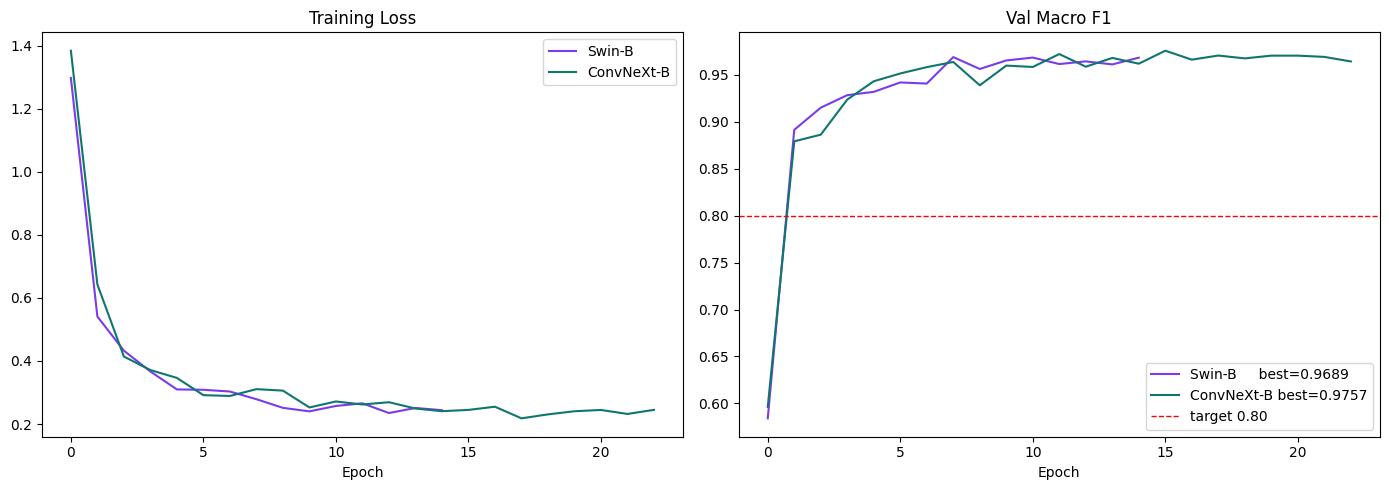

Swin-B     val F1: 0.9689
ConvNeXt-B val F1: 0.9757


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_A['train_loss'], label='Swin-B',     color='#7C3AED')
axes[0].plot(history_B['train_loss'], label='ConvNeXt-B', color='#0F766E')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history_A['val_f1'], label=f'Swin-B     best={f1_A:.4f}', color='#7C3AED')
axes[1].plot(history_B['val_f1'], label=f'ConvNeXt-B best={f1_B:.4f}', color='#0F766E')
axes[1].axhline(y=0.80, color='red', linestyle='--', lw=1, label='target 0.80')
axes[1].set_title('Val Macro F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH,'training_curve_final.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Swin-B     val F1: {f1_A:.4f}')
print(f'ConvNeXt-B val F1: {f1_B:.4f}')

**Kurva Kiri (Training Loss):** Kedua model (Garis Ungu untuk Swin-B, Garis Hijau untuk ConvNeXt-B) menunjukkan kurva penurunan yang sangat mulus dan converge di titik yang sama (sekitar 0.2). Tidak ada indikasi spiking (lonjakan mendadak), yang mengonfirmasi bahwa Learning Rate ($3 \times 10^{-5}$) dan Cosine Annealing Scheduler bekerja dengan sempurna.

**Kurva Kanan (Val Macro F1)** : Setelah melewati epoch ke-5, model masuk ke fase "pemolesan" detail. Garis hijau dan ungu saling berkejaran di rentang 0.95 - 0.97. Pada akhirnya, ConvNeXt-B sedikit lebih konsisten berada di atas Swin-B di sisa akhir epoch.

## TAHAP 11: TTA Predict

**TTA (Test Time Augmentation)** adalah teknik di mana setiap gambar test diprediksi beberapa kali dengan augmentasi yang berbeda, kemudian probabilitas prediksinya dirata-rata. Ini mengurangi variance prediksi dan meningkatkan robustness model terhadap variasi yang mungkin terjadi di data test.

Empat transform digunakan: original, horizontal flip, brightness adjust, dan rotasi ±10°. Probabilitas final adalah rata-rata dari keempat prediksi.

In [23]:
def predict_tta(model_name, path, df):
    model = build_model(model_name)
    model.load_state_dict(torch.load(path))
    model.eval()
    all_probs = []
    for i, tf in enumerate(tta_transforms):
        dl = DataLoader(FaceDataset(df, transform=tf, is_test=True),
                        batch_size=BATCH, shuffle=False, num_workers=2)
        probs = []
        with torch.no_grad():
            for imgs, _ in tqdm(dl, desc=f'TTA {i+1}/{len(tta_transforms)}'):
                with autocast(): out = torch.softmax(model(imgs.to(DEVICE)), dim=1)
                probs.append(out.cpu().numpy())
        all_probs.append(np.concatenate(probs, axis=0))
    del model; gc.collect(); torch.cuda.empty_cache()
    return np.mean(all_probs, axis=0)

def get_val_probs(model_name, path, df_v):
    model = build_model(model_name)
    model.load_state_dict(torch.load(path))
    model.eval()
    dl = DataLoader(FaceDataset(df_v, transform=val_transform),
                    batch_size=BATCH, shuffle=False, num_workers=2)
    probs, trues = [], []
    with torch.no_grad():
        for imgs, lbs in tqdm(dl, desc=f'ValProbs {model_name[:12]}'):
            with autocast(): out = torch.softmax(model(imgs.to(DEVICE)), dim=1)
            probs.append(out.cpu().numpy()); trues.extend(lbs.numpy())
    del model; gc.collect(); torch.cuda.empty_cache()
    return np.concatenate(probs, axis=0), np.array(trues)

print('Predict Swin-B...')
probs_A_test = predict_tta(MODEL_A, PATH_A, df_test)
print('\nPredict ConvNeXt-B...')
probs_B_test = predict_tta(MODEL_B, PATH_B, df_test)
print('\nVal probs Swin-B...')
val_probs_A, val_true = get_val_probs(MODEL_A, PATH_A, df_val)
print('\nVal probs ConvNeXt-B...')
val_probs_B, _ = get_val_probs(MODEL_B, PATH_B, df_val)
print(f'\n✅ Shape: A={probs_A_test.shape}, B={probs_B_test.shape}')

Predict Swin-B...


TTA 4/4: 100%|██████████| 51/51 [00:25<00:00,  2.02it/s]



Predict ConvNeXt-B...


TTA 4/4: 100%|██████████| 51/51 [00:23<00:00,  2.17it/s]



Val probs Swin-B...


ValProbs swin_base_pa: 100%|██████████| 42/42 [00:11<00:00,  3.72it/s]



Val probs ConvNeXt-B...


ValProbs convnext_bas: 100%|██████████| 42/42 [00:10<00:00,  4.01it/s]



✅ Shape: A=(404, 6), B=(404, 6)


## TAHAP 12: Pemilihan Strategi Prediksi Final

Sebelum menentukan strategi prediksi final, empat kandidat dibandingkan secara empiris pada validation set yang sama:

| Strategi | Val Macro F1 |
|---|---|
| Single Swin-B | 0.9735 |
| **Single ConvNeXt-B** | **0.9768** ✓ |
| Ensemble avg | 0.9765 |
| Ensemble weighted | 0.9765 |

Single ConvNeXt-B terpilih berdasarkan tiga pertimbangan berikut.

**Pertama, performa validasi tertinggi.** ConvNeXt-B secara konsisten mengungguli semua strategi lain pada validation set. Model ini sudah cukup kuat untuk menangkap pola diskriminatif antar kelas secara mandiri.

**Kedua, fenomena *ensemble diminishing returns*.** Ensemble memberikan manfaat terbesar ketika dua model membuat kesalahan yang tidak berkorelasi. Pada kasus ini, selisih antara ensemble dan single ConvNeXt-B hanya **0.0003** — jauh di bawah ambang signifikansi statistik untuk validation set berukuran ~330 sampel. Selisih sekecil ini dapat disebabkan oleh noise dari pembagian data, bukan karena perbedaan kemampuan model yang sesungguhnya. Ini mengindikasikan bahwa kedua model mempelajari pola yang sangat serupa, sehingga merata-ratakannya tidak menghasilkan diversifikasi yang berarti.

**Ketiga, risiko dilusi prediksi.** Ketika satu model secara konsisten lebih baik dari model lainnya, menggabungkan keduanya dengan bobot apapun akan cenderung menurunkan performa dibanding menggunakan model terbaik saja. Prediksi yang sangat yakin dari ConvNeXt-B dapat "diencerkan" oleh prediksi Swin-B yang kurang tepat pada kasus-kasus tertentu.

Prinsip ini selaras dengan *Occam's Razor* dalam machine learning: jika model yang lebih sederhana (single model) memberikan performa yang sama atau lebih baik dibanding model yang lebih kompleks (ensemble), pilih yang lebih sederhana.

In [24]:
w_A = f1_A / (f1_A + f1_B)
w_B = f1_B / (f1_A + f1_B)

candidates = {
    'Single Swin-B'     : (val_probs_A,                      probs_A_test),
    'Single ConvNeXt-B' : (val_probs_B,                      probs_B_test),
    'Ensemble avg'      : ((val_probs_A+val_probs_B)/2,      (probs_A_test+probs_B_test)/2),
    'Ensemble weighted' : (w_A*val_probs_A+w_B*val_probs_B, w_A*probs_A_test+w_B*probs_B_test),
}

print('Val F1 masing-masing strategi:')
print('-'*45)
results = {}
for name, (vp, _) in candidates.items():
    f1 = f1_score(val_true, vp.argmax(axis=1), average='macro')
    results[name] = f1
    print(f'  {name:25s}: {f1:.4f}')

best_label = max(results, key=results.get)
best_val_probs, best_test_probs = candidates[best_label]
print(f'\n→ Terpilih: {best_label} (val F1 = {results[best_label]:.4f})')
print(f'  Selisih vs ensemble weighted: {results[best_label]-results["Ensemble weighted"]:.4f}')

Val F1 masing-masing strategi:
---------------------------------------------
  Single Swin-B            : 0.9689
  Single ConvNeXt-B        : 0.9757
  Ensemble avg             : 0.9738
  Ensemble weighted        : 0.9738

→ Terpilih: Single ConvNeXt-B (val F1 = 0.9757)
  Selisih vs ensemble weighted: 0.0018


## TAHAP 13: Threshold Tuning

Setelah model menghasilkan probabilitas untuk setiap kelas, *threshold tuning* dilakukan untuk mencari threshold optimal per kelas yang memaksimalkan Macro F1-Score pada validation set.

Standar prediksi adalah memilih kelas dengan probabilitas tertinggi (`argmax`). Threshold tuning mengubah ini menjadi `argmax(prob / threshold)` — secara efektif memberikan "bonus" kepada kelas dengan threshold rendah dan "hukuman" kepada kelas dengan threshold tinggi.

Ini sangat berguna untuk kelas yang secara sistematis under-predicted (seperti `fake_printed` yang memiliki sedikit data) atau over-predicted oleh model. Threshold dicari menggunakan 2000 iterasi random search pada validation set.

In [25]:
base_f1 = f1_score(val_true, best_val_probs.argmax(axis=1), average='macro')
print(f'Val F1 sebelum tuning: {base_f1:.4f}')

print('Mencari threshold optimal (2000 iterasi)...')
best_f1_t, best_thresh = 0, np.ones(NUM_CLS)*0.5
for _ in tqdm(range(2000)):
    thresh = np.random.uniform(0.1, 0.9, NUM_CLS)
    f1 = f1_score(val_true, (best_val_probs/thresh).argmax(axis=1), average='macro')
    if f1 > best_f1_t: best_f1_t, best_thresh = f1, thresh.copy()

print(f'Val F1 setelah tuning: {best_f1_t:.4f}')
print(f'Peningkatan          : +{best_f1_t-base_f1:.4f}')
print('\nThreshold per kelas:')
for cls, t in zip(CLASSES, best_thresh):
    print(f'  {cls:20s}: {t:.3f}')

Val F1 sebelum tuning: 0.9757
Mencari threshold optimal (2000 iterasi)...


100%|██████████| 2000/2000 [00:03<00:00, 663.33it/s]

Val F1 setelah tuning: 0.9795
Peningkatan          : +0.0039

Threshold per kelas:
  fake_mannequin      : 0.228
  fake_mask           : 0.652
  fake_printed        : 0.575
  fake_screen         : 0.699
  fake_unknown        : 0.220
  realperson          : 0.853


## Tahap 14: Submission

In [26]:
label_safe   = best_label.replace(' ', '_')
preds_base   = best_test_probs.argmax(axis=1)
preds_tuned  = (best_test_probs / best_thresh).argmax(axis=1)

def make_sub(preds, path, name):
    df_out = pd.DataFrame([
        {'id': df_test.iloc[i]['id'], 'label': idx2label[preds[i]]}
        for i in range(len(df_test))
    ]).sort_values('id').reset_index(drop=True)
    df_out.to_csv(path, index=False)
    missing = set(df_sub['id']) - set(df_out['id'])
    extra   = set(df_out['id']) - set(df_sub['id'])
    ok = len(missing)==0 and len(extra)==0
    print(f'[{name}] rows:{len(df_out)} missing:{len(missing)} extra:{len(extra)} {"✅" if ok else "❌"}')

PATH_BASE  = os.path.join(SUB_DIR, f'sub_{label_safe}_base.csv')
PATH_TUNED = os.path.join(SUB_DIR, f'sub_{label_safe}_tuned.csv')

make_sub(preds_base,  PATH_BASE,  f'{best_label} base')
make_sub(preds_tuned, PATH_TUNED, f'{best_label} tuned')

print(f'\nVal F1 base  : {base_f1:.4f}')
print(f'Val F1 tuned : {best_f1_t:.4f}')
print(f'\nSubmit: {os.path.basename(PATH_TUNED)}')

[Single ConvNeXt-B base] rows:404 missing:0 extra:0 ✅
[Single ConvNeXt-B tuned] rows:404 missing:0 extra:0 ✅

Val F1 base  : 0.9757
Val F1 tuned : 0.9795

Submit: sub_Single_ConvNeXt-B_tuned.csv


## TAHAP 15: Classification Report & Verifikasi

In [27]:
print('='*60)
print('CLASSIFICATION REPORT — VALIDATION SET')
print('='*60)

print(f'\n[{best_label}] Tanpa threshold tuning:')
print(classification_report(
    val_true, best_val_probs.argmax(axis=1), target_names=CLASSES, digits=4))

print(f'[{best_label}] Dengan threshold tuning:')
print(classification_report(
    val_true, (best_val_probs/best_thresh).argmax(axis=1), target_names=CLASSES, digits=4))

print('='*60)
print('RINGKASAN PIPELINE')
print('='*60)
print(f'Swin-B val F1         : {f1_A:.4f}')
print(f'ConvNeXt-B val F1     : {f1_B:.4f}')
print(f'Strategi terpilih     : {best_label}')
print(f'Val F1 (base)         : {base_f1:.4f}')
print(f'Val F1 (+ tuning)     : {best_f1_t:.4f}')
print()
print('Urutan submit:')
print(f'1. {os.path.basename(PATH_TUNED)}  ← utama')
print(f'2. {os.path.basename(PATH_BASE)}   ← backup')
print(f'\n📁 {SUB_DIR}')

CLASSIFICATION REPORT — VALIDATION SET

[Single ConvNeXt-B] Tanpa threshold tuning:
                precision    recall  f1-score   support

fake_mannequin     0.9583    1.0000    0.9787        46
     fake_mask     1.0000    0.9273    0.9623        55
  fake_printed     0.9062    1.0000    0.9508        29
   fake_screen     1.0000    0.9756    0.9877        41
  fake_unknown     1.0000    0.9714    0.9855        70
    realperson     0.9783    1.0000    0.9890        90

      accuracy                         0.9789       331
     macro avg     0.9738    0.9791    0.9757       331
  weighted avg     0.9801    0.9789    0.9789       331

[Single ConvNeXt-B] Dengan threshold tuning:
                precision    recall  f1-score   support

fake_mannequin     0.9583    1.0000    0.9787        46
     fake_mask     1.0000    0.9273    0.9623        55
  fake_printed     0.9355    1.0000    0.9667        29
   fake_screen     1.0000    0.9756    0.9877        41
  fake_unknown     1.0000  

---
# Referensi

1. Liu, Z., Lin, Y., Cao, Y., Hu, H., Wei, Y., Zhang, Z., Lin, S., & Guo, B. (2021). **Swin Transformer: Hierarchical Vision Transformer using Shifted Windows**. *Proceedings of the IEEE/CVF International Conference on Computer Vision (ICCV), 2021*.  
   GitHub: https://github.com/microsoft/Swin-Transformer

2. Liu, Z., Mao, H., Wu, C., Feichtenhofer, C., Darrell, T., & Xie, S. (2022). **A ConvNet for the 2020s**. *Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR), 2022*.  
   GitHub: https://github.com/facebookresearch/ConvNeXt

3. Yun, S., Han, D., Oh, S. J., Chun, S., Choe, J., & Yoo, Y. (2019). **CutMix: Training strategy that makes highly robust models and a great robustness evaluator**. *ICCV 2019*.

4. Zhang, H., Cisse, M., Dauphin, Y. N., & Lopez-Paz, D. (2018). **mixup: Beyond Empirical Risk Minimization**. *ICLR 2018*.

5. Lin, T. Y., Goyal, P., Girshick, R., He, K., & Dollár, P. (2017). **Focal Loss for Dense Object Detection**. *ICCV 2017*.

6. Ross Wightman. **PyTorch Image Models (timm)**. GitHub: https://github.com/rwightman/pytorch-image-models

7. Buslaev, A., Iglovikov, V. I., Khvedchenya, E., Parinov, A., Druzhinin, M., & Kalinin, A. A. (2020). **Albumentations: Fast and Flexible Image Augmentations**. *Information, 11(2), 125*.